# Introduction & Project Summary 
cell_source = """# MambaIDS: Selective State Space Model for Real-Time DDoS Detection in IIoT Edge Networks

## Introduction

Distributed Denial-of-Service (DDoS) attacks targeting Industrial Internet of Things (IIoT)
infrastructure represent one of the most pressing cybersecurity challenges in modern networked
environments. As IIoT devices proliferate across critical sectors — manufacturing, energy,
healthcare, and smart infrastructure, their constrained hardware, heterogeneous protocols, and
always-on nature make them both high-value targets and difficult to protect using conventional
security tooling. Traditional Intrusion Detection Systems (IDS) based on Transformers or recurrent
architectures (GRU, LSTM) face a fundamental tension: they either lack the sequence memory needed
to capture temporal attack patterns, or they carry quadratic computational costs that make
real-time, CPU-only edge deployment infeasible.

**MambaIDS** addresses this gap by introducing ; for the first time , a Mamba Selective State
Space Model (SSM) as the temporal backbone of an IIoT DDoS detector. Mamba achieves linear-time
sequence modelling ('O(L)') with content-selective state updates, meaning the model dynamically
decides which network flow features are relevant to propagate across time steps. This makes it
uniquely suited to bursty, high-volume DDoS traffic where most packets are noise and only a
minority signal an active attack.

The architecture pairs the Mamba block with a CNN-based feature projection layer and a
Convolutional Block Attention Module (CBAM) to capture both spatial feature interactions and
temporal attack dynamics simultaneously. A trainable input projection layer normalises
variable-length feature vectors from different datasets into a shared 39-dimensional latent space,
enabling sequential cross-dataset transfer learning without retraining the core model from scratch.

---

## Key Contributions

- **First Mamba SSM application to IIoT DDoS detection** - replaces Transformer/GRU backbones
  with a linear-time, content-selective sequence model.
- **Trainable feature projection layer** - maps heterogeneous input dimensions
  (78 → 33 → 47 features) to a unified 39-dimensional latent space for cross-dataset transfer.
- **CBAM attention after Mamba** - focuses channel and spatial attention on bursty attack patterns.
- **Three-dataset sequential transfer learning** - pre-train on CIC-DDoS2019, fine-tune on
  Edge-IIoTset and CICIoT23 with the Mamba/CBAM core frozen.
- **Rigorous statistical validation** - 10-seed evaluation with 95% confidence intervals and
  Shapiro-Wilk normality tests.
- **CPU-only edge deployment benchmarking** - full latency and throughput profiling targeting
  real-world IIoT edge hardware constraints.

---

## Why Mamba over Transformer / GRU?

| Property            | Transformer | GRU    | **Mamba SSM**  |
|---------------------|:-----------:|:------:|:--------------:|
| Time complexity     | O(L²)       | O(L)   | **O(L)**       |
| Long-range memory   | ✓           | x      | **✓**          |
| Content-selectivity | x           | x      | **✓**          |
| Edge (CPU) speed    | Slow        | Medium | **Fast**       |
| Prior IIoT DDoS use | Yes         | Yes    | **First**      |

---

## Architecture Overview

In [1]:
# CELL 1: Environment Setup & Global Configuration
import os, gc, random, time, warnings, json, platform
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve
)
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from tqdm import tqdm
warnings.filterwarnings('ignore')

print('CELL 1: Environment Setup\n')

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_CORES = os.cpu_count() or 4
torch.set_num_threads(N_CORES)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

# Global Hyperparameters
PROJ_DIM    = 39      # projection dimension (same as baseline paper)
SEQ_LEN     = 16      # sliding window
D_MODEL     = 64      # Mamba model dimension
D_STATE     = 16      # SSM state dimension
D_CONV      = 4       # Mamba conv kernel size
EXPAND      = 2       # Mamba expansion factor
N_LAYERS    = 2       # number of Mamba blocks
DROPOUT     = 0.25
BATCH_TRAIN = 256
BATCH_INFER = 512
EPOCHS_PRE  = 25      # pre-training epochs
EPOCHS_FT   = 20      # fine-tuning epochs
LR_PRE      = 1e-3
LR_FT       = 3e-4
PATIENCE    = 7
IS_WINDOWS  = platform.system() == 'Windows'
NUM_WORKERS = 0 if IS_WINDOWS else min(4, N_CORES)
USE_COMPILE = hasattr(torch, 'compile')

OUT = Path('outputs')
OUT.mkdir(exist_ok=True)

print(f'Device      : {device}')
print(f'CPU Threads : {torch.get_num_threads()}')
print(f'PROJ_DIM={PROJ_DIM} | D_MODEL={D_MODEL} | D_STATE={D_STATE} | SEQ_LEN={SEQ_LEN}')
print(f'N_LAYERS={N_LAYERS} | EXPAND={EXPAND} | DROPOUT={DROPOUT}')
print('Setup complete.\n')

CELL 1: Environment Setup

Device      : cpu
CPU Threads : 16
PROJ_DIM=39 | D_MODEL=64 | D_STATE=16 | SEQ_LEN=16
N_LAYERS=2 | EXPAND=2 | DROPOUT=0.25
Setup complete.



In [2]:
# CELL 2: Dataset Paths
BASE_PATH = Path(r'F:\jupyter\kagglehub')

DATASET_PATHS = {
    'cic_ddos': {
        'root': BASE_PATH / r'datasets\dhoogla\cicddos2019\versions\3',
        'split': False
    },
    'edge_iot': {
        'root': BASE_PATH / r'edgeiiotset-cyber-security-dataset-of-iot-iiot\versions\5'
                            r'\Edge-IIoTset dataset\Selected dataset for ML and DL',
        'split': False
    },
    'ciciot23': {
        'train': BASE_PATH / r'CICIOT23\train\train.csv',
        'val':   BASE_PATH / r'CICIOT23\validation\validation.csv',
        'test':  BASE_PATH / r'CICIOT23\test\test.csv',
        'split': True
    }
}

print('Dataset paths configured.')
for k, v in DATASET_PATHS.items():
    if v['split']:
        exists = all(Path(v[s]).exists() for s in ['train', 'val', 'test'])
    else:
        exists = v['root'].exists()
    print(f'  {k}: {"FOUND" if exists else "NOT FOUND"}')

Dataset paths configured.
  cic_ddos: FOUND
  edge_iot: FOUND
  ciciot23: FOUND


In [3]:
# CELL 3: CIC-DDoS / Edge-IIoTset / CICIoT23 Loader
print('CELL 3: Loading datasets\n')

datasets = {}

def to_binary(x):
    if pd.isna(x): return 0
    x = str(x).lower()
    return 0 if ('normal' in x or 'benign' in x or x == '0') else 1

def read_any(f):
    try:
        return pd.read_csv(f, low_memory=False) if f.suffix == '.csv' else pd.read_parquet(f)
    except Exception as e:
        print(f'  [!] Cannot read {f.name}: {e}'); return None

def get_numeric_cols(df):
    df = df.copy()
    target_col = df['target'].copy() if 'target' in df.columns else None
    bad = [c for c in df.columns if c != 'target' and
           df[c].dtype.name in ('object', 'category')]
    df.drop(columns=bad, inplace=True)
    for col in df.columns:
        if col != 'target': df[col] = pd.to_numeric(df[col], errors='coerce')
    df.dropna(axis=1, how='all', inplace=True)
    if target_col is not None and 'target' not in df.columns:
        df['target'] = target_col
    return df, [c for c in df.columns if c != 'target']

def load_folder(root):
    files = list(root.rglob('*.csv')) + list(root.rglob('*.parquet'))
    dfs = []
    for f in files:
        df = read_any(f)
        if df is None: continue
        label_col = next((c for c in ['Label','label','Attack_type','attack_type','class']
                          if c in df.columns), None)
        if label_col is None: continue
        df['target'] = df[label_col].apply(to_binary).astype('int8')
        df, num_cols = get_numeric_cols(df)
        if not num_cols: continue
        df = df[num_cols + ['target']]
        dfs.append(df)
        n_att = df['target'].sum()
        print(f'  {f.name}: {len(df):>10,} rows (attack={n_att:,} / benign={len(df)-n_att:,})')
    if not dfs: return None
    return pd.concat(dfs, ignore_index=True).fillna(0)

def load_split_safe(p, chunksize=200_000, sample_frac=None, max_rows=None):
    """
    Memory-safe chunked CSV loader with optional stratified downsampling.
    - chunksize   : rows per chunk (reduce to 100_000 if still OOM)
    - sample_frac : stratified fraction to keep per chunk (None = keep all)
    - max_rows    : hard cap on total rows loaded
    """
    p = Path(p)
    print(f'  Loading {p.name} in chunks of {chunksize:,}...')
    label_col = None
    chunks    = []
    total     = 0

    for chunk in pd.read_csv(p, chunksize=chunksize, low_memory=False):
        if label_col is None:
            label_col = next(
                (c for c in ['Label','label','Attack_type','attack_type','class']
                 if c in chunk.columns), None)
            if label_col is None:
                raise ValueError(f'No label column found in {p.name}')

        chunk['target'] = chunk[label_col].apply(to_binary).astype('int8')
        chunk, num_cols = get_numeric_cols(chunk)
        chunk = chunk[num_cols + ['target']].fillna(0)

        if sample_frac is not None and sample_frac < 1.0:
            n_keep = max(2, int(len(chunk) * sample_frac))
            atk    = chunk[chunk['target'] == 1]
            ben    = chunk[chunk['target'] == 0]
            n_a    = max(1, int(n_keep * len(atk) / (len(atk) + len(ben) + 1e-8)))
            n_b    = n_keep - n_a
            chunk  = pd.concat([
                atk.sample(min(n_a, len(atk)), random_state=SEED),
                ben.sample(min(n_b, len(ben)), random_state=SEED)
            ], ignore_index=True)

        chunks.append(chunk)
        total += len(chunk)
        print(f'    chunk: {len(chunk):,} rows  (total so far: {total:,})')

        if max_rows is not None and total >= max_rows:
            print(f'    max_rows={max_rows:,} reached, stopping.')
            break

    df_out = pd.concat(chunks, ignore_index=True)
    n_att  = int(df_out['target'].sum())
    print(f'  Done: {len(df_out):,} rows  '
          f'(attack={n_att:,} / benign={len(df_out)-n_att:,})')
    return df_out


# Load CIC-DDoS2019
print('Loading CIC-DDoS2019...')
cic = load_folder(DATASET_PATHS['cic_ddos']['root'])
datasets['cic_ddos'] = {
    'df': cic,
    'features': [c for c in cic.columns if c != 'target']
}
print(f'CIC-DDoS total: {len(cic):,} | features: {len(datasets["cic_ddos"]["features"])}\n')


# Load Edge-IIoTset
print('Loading Edge-IIoTset...')
edge = load_folder(DATASET_PATHS['edge_iot']['root'])
datasets['edge_iot'] = {
    'df': edge,
    'features': [c for c in edge.columns if c != 'target']
}
print(f'Edge-IIoTset total: {len(edge):,} | features: {len(datasets["edge_iot"]["features"])}\n')


# Load CICIoT23 (chunked, memory-safe)

SAMPLE_FRAC = 0.3   # adjust if still OOM

print('Loading CICIoT23...')
train23 = load_split_safe(
    DATASET_PATHS['ciciot23']['train'],
    chunksize=200_000,
    sample_frac=SAMPLE_FRAC
)
val23 = load_split_safe(
    DATASET_PATHS['ciciot23']['val'],
    chunksize=200_000,
    sample_frac=1.0        # always load full val
)
test23 = load_split_safe(
    DATASET_PATHS['ciciot23']['test'],
    chunksize=200_000,
    sample_frac=1.0        # always load full test
)

datasets['ciciot23'] = {
    'train':    train23,
    'val':      val23,
    'test':     test23,
    'features': [c for c in train23.columns if c != 'target']
}
print(f'CICIoT23: train={len(train23):,} | val={len(val23):,} | test={len(test23):,}')
print(f'  features: {len(datasets["ciciot23"]["features"])}')
print('\nCELL 3 COMPLETE')

CELL 3: Loading datasets

Loading CIC-DDoS2019...
  DNS-testing.parquet:      6,703 rows (attack=3,669 / benign=3,034)
  LDAP-testing.parquet:      2,831 rows (attack=1,440 / benign=1,391)
  LDAP-training.parquet:      6,715 rows (attack=2,130 / benign=4,585)
  MSSQL-testing.parquet:      8,083 rows (attack=6,212 / benign=1,871)
  MSSQL-training.parquet:     10,974 rows (attack=8,400 / benign=2,574)
  NetBIOS-testing.parquet:      2,225 rows (attack=598 / benign=1,627)
  NetBIOS-training.parquet:      1,631 rows (attack=398 / benign=1,233)
  NTP-testing.parquet:    134,674 rows (attack=121,368 / benign=13,306)
  Portmap-training.parquet:      5,105 rows (attack=685 / benign=4,420)
  SNMP-testing.parquet:      4,018 rows (attack=2,717 / benign=1,301)
  Syn-testing.parquet:        907 rows (attack=533 / benign=374)
  Syn-training.parquet:     70,336 rows (attack=43,302 / benign=27,034)
  TFTP-testing.parquet:    121,833 rows (attack=98,917 / benign=22,916)
  UDP-testing.parquet:     12,4

In [4]:
# CELL 4: Feature Engineering & Scaling
print('CELL 4: Feature Engineering & Scaling\n')

# After RobustScaler, clipping to [-100, 100] to kill any remaining outlier columns
CLIP_VAL = 100.0

scalers   = {}
feat_cols = {}

def remove_low_variance(df, feats, threshold=1e-6):
    var  = df[feats].var()
    keep = var[var > threshold].index.tolist()
    dropped = len(feats) - len(keep)
    if dropped: print(f'   Dropped {dropped} near-zero-variance features')
    return keep

def remove_high_correlation(df, feats, threshold=0.98):
    sample = df[feats].sample(min(50_000, len(df)), random_state=SEED)
    corr   = sample.corr().abs()
    upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    drop   = [c for c in upper.columns if (upper[c] > threshold).any()]
    keep   = [c for c in feats if c not in drop]
    if drop: print(f'   Dropped {len(drop)} high-corr features (>{threshold})')
    return keep

for name, data in datasets.items():
    print(f'[{name.upper()}]')
    feats = data.get('features', [])

    if name in ['cic_ddos', 'edge_iot']:
        df    = data['df']
        X     = np.nan_to_num(df[feats].values,
                               nan=0., posinf=0., neginf=0.)
        y     = df['target'].values.astype(np.int64)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.20, stratify=y, random_state=SEED)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_tr, y_tr, test_size=0.125, stratify=y_tr, random_state=SEED)
        tr_df = pd.DataFrame(X_tr, columns=feats)

    else:  # ciciot23
        tr_df_raw  = data['train']
        val_df_raw = data['val']
        te_df_raw  = data['test']
        X_tr  = np.nan_to_num(tr_df_raw[feats].values,
                               nan=0., posinf=0., neginf=0.)
        X_val = np.nan_to_num(val_df_raw[feats].values,
                               nan=0., posinf=0., neginf=0.)
        X_te  = np.nan_to_num(te_df_raw[feats].values,
                               nan=0., posinf=0., neginf=0.)
        y_tr  = tr_df_raw['target'].values.astype(np.int64)
        y_val = val_df_raw['target'].values.astype(np.int64)
        y_te  = te_df_raw['target'].values.astype(np.int64)
        tr_df = pd.DataFrame(X_tr, columns=feats)

    kept    = remove_low_variance(tr_df, feats)
    kept    = remove_high_correlation(tr_df[kept], kept)
    feat_cols[name] = kept
    col_idx = [feats.index(c) for c in kept]

    scaler  = RobustScaler()
    scaler.fit(X_tr[:, col_idx])
    scalers[name] = scaler

    def scale_and_clip(X):
        out = scaler.transform(X[:, col_idx]).astype(np.float32)
        out = np.nan_to_num(out, nan=0., posinf=0., neginf=0.)
        out = np.clip(out, -CLIP_VAL, CLIP_VAL)
        return out

    datasets[name]['X_train'] = scale_and_clip(X_tr)
    datasets[name]['X_val']   = scale_and_clip(X_val)
    datasets[name]['X_test']  = scale_and_clip(X_te)
    datasets[name]['y_train'] = y_tr
    datasets[name]['y_val']   = y_val
    datasets[name]['y_test']  = y_te

    tr_pos = y_tr.sum(); tr_tot = len(y_tr)
    arr    = datasets[name]['X_train']
    print(f'   Features kept : {len(kept)}')
    print(f'   Train         : {tr_tot:,} '
          f'(attack rate {tr_pos/tr_tot*100:.1f}%)')
    print(f'   Val           : {len(y_val):,}')
    print(f'   Test          : {len(y_te):,}')
    print(f'   X_train range : [{arr.min():.2f}, {arr.max():.2f}]')
    print()

print('CELL 4 COMPLETE')

CELL 4: Feature Engineering & Scaling

[CIC_DDOS]
   Dropped 12 near-zero-variance features
   Dropped 15 high-corr features (>0.98)
   Features kept : 50
   Train         : 301,959 (attack rate 77.3%)
   Val           : 43,137
   Test          : 86,275
   X_train range : [-100.00, 100.00]

[EDGE_IOT]
   Dropped 4 near-zero-variance features
   Dropped 6 high-corr features (>0.98)
   Features kept : 33
   Train         : 1,663,900 (attack rate 31.0%)
   Val           : 237,700
   Test          : 475,401
   X_train range : [-1.00, 100.00]

[CICIOT23]
   Dropped 3 near-zero-variance features
   Dropped 6 high-corr features (>0.98)
   Features kept : 37
   Train         : 1,647,591 (attack rate 97.6%)
   Val           : 1,176,851
   Test          : 1,176,851
   X_train range : [-100.00, 100.00]

CELL 4 COMPLETE


In [5]:
# CELL 5: MambaDDoS Architecture Definition
print('CELL 5: MambaIDS Architecture\n')

# 5.1 Selective State Space (Mamba) Block
class SelectiveSSM(nn.Module):
    """
    Numerically stable pure-PyTorch Mamba SSM block.
    Uses parallel associative scan instead of Python for-loop
    for both stability and speed.
    """
    def __init__(self, d_model: int, d_state: int = 16,
                 d_conv: int = 4, expand: int = 2):
        super().__init__()
        self.d_model  = d_model
        self.d_state  = d_state
        self.d_inner  = int(expand * d_model)
        self.d_conv   = d_conv

        # Input projection (value + gate)
        self.in_proj  = nn.Linear(d_model, self.d_inner * 2, bias=False)

        # Depthwise conv for local context
        self.conv1d   = nn.Conv1d(
            self.d_inner, self.d_inner,
            kernel_size=d_conv, groups=self.d_inner,
            padding=d_conv - 1, bias=True
        )

        # Input-dependent SSM parameters
        self.x_proj   = nn.Linear(self.d_inner,
                                   d_state + d_state + 1, bias=False)
        self.dt_proj  = nn.Linear(1, self.d_inner, bias=True)

        # A (log-parameterised, negative for stability)
        A = torch.arange(1, d_state + 1,
                         dtype=torch.float32).unsqueeze(0).expand(
                         self.d_inner, -1)
        self.A_log    = nn.Parameter(torch.log(A))

        # D skip weight
        self.D        = nn.Parameter(torch.ones(self.d_inner))

        # Output projection
        self.out_proj = nn.Linear(self.d_inner, d_model, bias=False)
        self.norm     = nn.LayerNorm(d_model)

        # Initialising dt_proj bias so softplus(bias) ≈ 0.1  (stable start)
        nn.init.constant_(self.dt_proj.bias, -2.0)

    def selective_scan_stable(self, u, delta, A, B, C, D):
        """
        Parallel-prefix (associative) scan — O(L log L) but fully
        vectorised; no Python loop over L.

        u     : (B, L, d_inner)
        delta : (B, L, d_inner)   already softplus-ed, clamped
        A     : (d_inner, d_state)
        B     : (B, L, d_state)
        C     : (B, L, d_state)
        D     : (d_inner,)
        """
        B_sz, L, d = u.shape
        N          = A.shape[-1]

        # Clamp delta to prevent overflow in exp
        delta = delta.clamp(min=-4.0, max=4.0)

        # Discretise: dA (B, L, d_inner, d_state), dB (B, L, d_inner, d_state)
        # A is negative so -A is positive; exp(-A*delta) < 1 always
        dA = torch.exp(
            delta.unsqueeze(-1) *                         # (B,L,d,1)
            A.unsqueeze(0).unsqueeze(0)                   # (1,1,d,N)
        ).clamp(max=1.0 - 1e-6)                           # keep < 1

        dB = (delta.unsqueeze(-1) *                       # (B,L,d,1)
              B.unsqueeze(2))                             # (B,L,1,N)

        # Parallel scan via cumulative product trick
        # h_t = dA_t * h_{t-1} + dB_t * u_t
        # We compute using log-space prefix products for dA
        log_dA   = torch.log(dA.clamp(min=1e-8))         # (B,L,d,N)
        cum_logA = torch.cumsum(log_dA, dim=1)            # prefix log-prod
        cum_A    = torch.exp(cum_logA)                    # (B,L,d,N)

        # Scaled inputs: v_t = dB_t * u_t / cum_A_t  (then cumsum, rescale)
        u_exp    = u.unsqueeze(-1)                        # (B,L,d,1)
        v        = dB * u_exp / (cum_A + 1e-8)           # (B,L,d,N)
        v_cs     = torch.cumsum(v, dim=1)                 # (B,L,d,N)
        h        = cum_A * v_cs                           # (B,L,d,N)

        # Output: y_t = sum_N h_t * C_t
        y = (h * C.unsqueeze(2)).sum(dim=-1)              # (B,L,d_inner)

        return y + u * D.unsqueeze(0).unsqueeze(0)

    def forward(self, x):
        """x : (B, L, d_model) → (B, L, d_model)"""
        residual = x
        x        = self.norm(x)

        # Split into value and gate branches
        xz       = self.in_proj(x)                       # (B,L,2*d_inner)
        x_, z    = xz.chunk(2, dim=-1)                   # (B,L,d_inner) each

        # Depthwise conv (causal padding trim)
        x_t      = x_.transpose(1, 2)                    # (B,d_inner,L)
        x_t      = self.conv1d(x_t)[..., :x.shape[1]]
        x_       = F.silu(x_t.transpose(1, 2))           # (B,L,d_inner)

        # Input-dependent SSM parameters
        ssm_p    = self.x_proj(x_)                       # (B,L,2N+1)
        B_p      = ssm_p[..., :self.d_state]
        C_p      = ssm_p[..., self.d_state:2*self.d_state]
        dt_raw   = ssm_p[..., -1:]                       # (B,L,1)
        delta    = F.softplus(self.dt_proj(dt_raw))      # (B,L,d_inner)

        A        = -torch.exp(self.A_log.float())        # (d_inner,d_state)

        y        = self.selective_scan_stable(
                       x_, delta, A, B_p, C_p, self.D)

        # Gate + output projection + residual
        y        = y * F.silu(z)
        return self.out_proj(y) + residual


# 5.2 CBAM Attention
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(channels, max(1, channels // reduction)),
            nn.ReLU(),
            nn.Linear(max(1, channels // reduction), channels)
        )
    def forward(self, x):
        # x: (B, C, L)
        avg = self.mlp(x.mean(dim=-1))
        mx  = self.mlp(x.amax(dim=-1))
        return torch.sigmoid(avg + mx).unsqueeze(-1) * x

class SpatialAttention(nn.Module):
    def __init__(self, kernel=7):
        super().__init__()
        self.conv = nn.Conv1d(2, 1, kernel_size=kernel,
                              padding=kernel // 2, bias=False)
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.amax(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1))) * x

class CBAM(nn.Module):
    def __init__(self, channels, reduction=8, kernel=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(kernel)
    def forward(self, x):
        return self.sa(self.ca(x))


# 5.3 MambaIDS Full Model 
class MambaIDS(nn.Module):
    """
    MambaIDS: Selective SSM + CBAM + projection layer for IIoT DDoS detection.

    Input(F) → Linear projection(F→proj_dim)
             → N x MambaBlock(d_model, stable parallel scan)
             → CBAM(d_model)
             → GlobalAvgPool
             → concat with projected skip
             → MLP classifier
             → sigmoid
    """
    def __init__(self, input_dim: int, proj_dim: int = 39,
                 d_model: int = 64, d_state: int = 16,
                 d_conv: int = 4, expand: int = 2,
                 n_layers: int = 2, dropout: float = 0.25,
                 finetune_mode: bool = False):
        super().__init__()
        self.proj_dim = proj_dim

        # Feature projection -re-initialised per dataset
        self.proj = nn.Sequential(
            nn.Linear(input_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.GELU()
        )

        # Embed scalar proj_dim → d_model
        self.embed = nn.Linear(proj_dim, d_model)

        # Mamba SSM blocks
        self.mamba_layers = nn.ModuleList([
            SelectiveSSM(d_model, d_state, d_conv, expand)
            for _ in range(n_layers)
        ])

        # CBAM
        self.cbam = CBAM(d_model)

        # MLP classifier
        combined = d_model + proj_dim
        if finetune_mode:
            self.classifier = nn.Sequential(
                nn.Linear(combined, 128), nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(128, 64), nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(64, 32), nn.ReLU(),
                nn.Linear(32, 1)
            )
        else:
            self.classifier = nn.Sequential(
                nn.Linear(combined, 256), nn.ReLU(),
                nn.Linear(256, 128), nn.ReLU(),
                nn.Linear(128, 64), nn.ReLU(),
                nn.Linear(64, 1)
            )

    def get_mamba_params(self):
        params = []
        for layer in self.mamba_layers:
            params.extend(layer.parameters())
        params.extend(self.embed.parameters())
        params.extend(self.cbam.parameters())
        return params

    def freeze_mamba(self):
        for p in self.get_mamba_params():
            p.requires_grad_(False)
        print('  Mamba blocks frozen (projection + classifier trainable)')

    def unfreeze_all(self):
        for p in self.parameters():
            p.requires_grad_(True)

    def forward(self, x):
        """x : (B, L, input_dim) → (B, 1) logit"""
        # Sanitise input
        x    = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        z    = self.proj(x)                               # (B,L,proj_dim)
        skip = z[:, -1, :]                                # (B,proj_dim)

        h    = self.embed(z)                              # (B,L,d_model)
        for mamba in self.mamba_layers:
            h = mamba(h)

        # CBAM
        h    = self.cbam(h.transpose(1, 2)).transpose(1, 2)
        h    = h.mean(dim=1)                              # (B,d_model)

        out  = torch.cat([h, skip], dim=-1)
        return self.classifier(out)


# 5.4 Dataset utility
class SlidingWindowDataset(Dataset):
    def __init__(self, X, y, seq_len):
        self.X       = torch.from_numpy(np.ascontiguousarray(X)).float()
        self.y       = torch.from_numpy(y.astype(np.float32))
        self.seq_len = seq_len
        self.n       = max(0, len(X) - seq_len + 1)
    def __len__(self): return self.n
    def __getitem__(self, i):
        return self.X[i:i+self.seq_len], self.y[i+self.seq_len-1]


# 5.5 Parameter count
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

n_feat_demo = len(feat_cols.get('cic_ddos', list(range(50))))
_demo = MambaIDS(n_feat_demo, PROJ_DIM, D_MODEL, D_STATE,
                 D_CONV, EXPAND, N_LAYERS, DROPOUT)
print(f'MambaIDS parameter count (F={n_feat_demo}): {count_params(_demo):,}')
del _demo

print('\nMambaIDS architecture ready.')
print('Key components:')
print('  1. Linear projection layer  (dataset-agnostic, re-init per transfer)')
print('  2. Mamba embed layer        (proj_dim → d_model)')
print(f'  3. {N_LAYERS}x SelectiveSSM blocks    '
      f'(stable parallel scan, d_model={D_MODEL}, d_state={D_STATE})')
print(f'  4. CBAM attention          (channel + spatial, {D_MODEL} channels)')
print('  5. GlobalAvgPool + skip connection')
print('  6. MLP classifier          (with dropout)')
print('\nCELL 5 COMPLETE')

CELL 5: MambaIDS Architecture

MambaIDS parameter count (F=50): 137,578

MambaIDS architecture ready.
Key components:
  1. Linear projection layer  (dataset-agnostic, re-init per transfer)
  2. Mamba embed layer        (proj_dim → d_model)
  3. 2x SelectiveSSM blocks    (stable parallel scan, d_model=64, d_state=16)
  4. CBAM attention          (channel + spatial, 64 channels)
  5. GlobalAvgPool + skip connection
  6. MLP classifier          (with dropout)

CELL 5 COMPLETE


In [6]:
# CELL 6: Training Functions & Single-Run Training
print('CELL 6: Training Functions & Single-Run Training\n')

# Sanitise all dataset arrays first
print('Sanitising all dataset arrays...')
for ds_name in datasets:
    for split in ['X_train', 'X_val', 'X_test']:
        if split in datasets[ds_name]:
            arr = datasets[ds_name][split]
            arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
            datasets[ds_name][split] = arr
print('Sanitisation complete.\n')

# Diagnostic: confirm no nan/inf remain
for ds_name in datasets:
    if 'X_train' in datasets[ds_name]:
        arr = datasets[ds_name]['X_train']
        print(f'{ds_name}: shape={arr.shape}  '
              f'min={arr.min():.4f}  max={arr.max():.4f}  '
              f'nan={np.isnan(arr).sum()}  inf={np.isinf(arr).sum()}')
print()


# Helper functions
def pw(y):
    """Safe pos_weight capped at 50 to prevent exploding loss."""
    n_pos = int(y.sum())
    n_neg = len(y) - n_pos
    if n_pos == 0:
        return 1.0
    return float(min(n_neg / n_pos, 50.0))


def make_loaders(data, seq_len, batch_train, batch_infer, num_workers=0):
    X_tr  = data['X_train'];  y_tr  = data['y_train']
    X_val = data.get('X_val', X_tr[:1])
    y_val = data.get('y_val', y_tr[:1])
    X_te  = data['X_test'];   y_te  = data['y_test']
    tr_ds  = SlidingWindowDataset(X_tr,  y_tr,  seq_len)
    val_ds = SlidingWindowDataset(X_val, y_val, seq_len)
    te_ds  = SlidingWindowDataset(X_te,  y_te,  seq_len)
    tr_ldr  = DataLoader(tr_ds,  batch_train,  shuffle=True,
                         num_workers=num_workers)
    val_ldr = DataLoader(val_ds, batch_infer, shuffle=False,
                         num_workers=num_workers)
    te_ldr  = DataLoader(te_ds,  batch_infer, shuffle=False,
                         num_workers=num_workers)
    return tr_ldr, val_ldr, te_ldr


def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb).squeeze(1)
        if torch.isnan(logits).any():
            print('  [!] NaN in logits - skipping batch')
            continue
        loss = criterion(logits, yb)
        if torch.isnan(loss):
            print('  [!] NaN loss - skipping batch')
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / max(n_batches, 1)


@torch.no_grad()
def eval_f1(model, loader, device, threshold=0.5):
    model.eval()
    probs, labels = [], []
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        p  = torch.sigmoid(model(xb.to(device)).squeeze(1)).cpu().numpy()
        probs.extend(p)
        labels.extend(yb.numpy())
    return (f1_score(labels,
                     (np.array(probs) >= threshold).astype(int),
                     zero_division=0),
            np.array(probs),
            np.array(labels))


def train_model(model, tr_ldr, val_ldr, epochs, lr, patience,
                pos_weight, device, tag=''):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device))
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        total_steps=epochs * len(tr_ldr))

    best_f1, best_state, patience_ctr = 0.0, None, 0
    history = []

    for ep in range(1, epochs + 1):
        loss = train_epoch(model, tr_ldr, criterion,
                           optimizer, scheduler, device)
        val_f1, _, _ = eval_f1(model, val_ldr, device)
        history.append({'epoch': ep, 'loss': loss, 'val_f1': val_f1})
        print(f'  [{tag}] E{ep:02d} | loss={loss:.4f} | val_F1={val_f1:.4f}')

        if val_f1 > best_f1:
            best_f1      = val_f1
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  [{tag}] Early stop at epoch {ep} '
                      f'(best val_F1={best_f1:.4f})')
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, history, best_f1


# STEP 1: Pre-train on CIC-DDoS2019
print('STEP 1: Pre-train on CIC-DDoS2019')
print('-' * 60)

n_feat_cic = datasets['cic_ddos']['X_train'].shape[1]
model_pre  = MambaIDS(n_feat_cic, PROJ_DIM, D_MODEL, D_STATE,
                      D_CONV, EXPAND, N_LAYERS, DROPOUT).to(device)

tr_ldr_cic, val_ldr_cic, te_ldr_cic = make_loaders(
    datasets['cic_ddos'], SEQ_LEN, BATCH_TRAIN, BATCH_INFER, NUM_WORKERS)

model_pre, hist_pre, best_pre = train_model(
    model_pre, tr_ldr_cic, val_ldr_cic,
    15, LR_PRE, PATIENCE,
    pw(datasets['cic_ddos']['y_train']),
    device, tag='CIC-DDoS PRE')

torch.save(model_pre.state_dict(), OUT / 'mambids_pretrained_cic.pth')
print(f'Pre-trained model saved. Best val F1={best_pre:.4f}\n')


# STEP 2: Fine-tune on Edge-IIoTset (Mamba frozen)
print('STEP 2: Fine-tune on Edge-IIoTset (Mamba frozen)')
print('-' * 60)

n_feat_edge = datasets['edge_iot']['X_train'].shape[1]
model_edge  = MambaIDS(n_feat_edge, PROJ_DIM, D_MODEL, D_STATE,
                       D_CONV, EXPAND, N_LAYERS, DROPOUT,
                       finetune_mode=True).to(device)

pre_sd        = model_pre.state_dict()
edge_sd       = model_edge.state_dict()
transfer_keys = [k for k in pre_sd
                 if k.startswith(('mamba_layers', 'embed', 'cbam'))]
for k in transfer_keys:
    if k in edge_sd and pre_sd[k].shape == edge_sd[k].shape:
        edge_sd[k] = pre_sd[k].clone()
model_edge.load_state_dict(edge_sd)
model_edge.freeze_mamba()
print(f'  Transferred {len(transfer_keys)} Mamba/CBAM parameter tensors')

tr_ldr_edge, val_ldr_edge, te_ldr_edge = make_loaders(
    datasets['edge_iot'], SEQ_LEN, BATCH_TRAIN, BATCH_INFER, NUM_WORKERS)

model_edge, hist_edge, best_edge = train_model(
    model_edge, tr_ldr_edge, val_ldr_edge,
    15, LR_FT, PATIENCE,
    pw(datasets['edge_iot']['y_train']),
    device, tag='Edge-IIoT FT')

torch.save(model_edge.state_dict(), OUT / 'mambids_edge_iot.pth')
print(f'Edge-IIoT model saved. Best val F1={best_edge:.4f}\n')


# STEP 3: Fine-tune on CICIoT23 (Mamba frozen)
print('STEP 3: Fine-tune on CICIoT23 (Mamba frozen)')
print('-' * 60)

n_feat_ciot = datasets['ciciot23']['X_train'].shape[1]
model_ciot  = MambaIDS(n_feat_ciot, PROJ_DIM, D_MODEL, D_STATE,
                       D_CONV, EXPAND, N_LAYERS, DROPOUT,
                       finetune_mode=True).to(device)

ciot_sd = model_ciot.state_dict()
for k in transfer_keys:
    if k in ciot_sd and pre_sd[k].shape == ciot_sd[k].shape:
        ciot_sd[k] = pre_sd[k].clone()
model_ciot.load_state_dict(ciot_sd)
model_ciot.freeze_mamba()
print(f'  Transferred {len(transfer_keys)} Mamba/CBAM parameter tensors')

tr_ldr_ciot, val_ldr_ciot, te_ldr_ciot = make_loaders(
    datasets['ciciot23'], SEQ_LEN, BATCH_TRAIN, BATCH_INFER, NUM_WORKERS)

model_ciot, hist_ciot, best_ciot = train_model(
    model_ciot, tr_ldr_ciot, val_ldr_ciot,
    15, LR_FT, PATIENCE,
    pw(datasets['ciciot23']['y_train']),
    device, tag='CICIoT23 FT')

torch.save(model_ciot.state_dict(), OUT / 'mambids_ciciot23.pth')
print(f'CICIoT23 model saved. Best val F1={best_ciot:.4f}\n')
print('CELL 6 COMPLETE')

CELL 6: Training Functions & Single-Run Training

Sanitising all dataset arrays...
Sanitisation complete.

cic_ddos: shape=(301959, 50)  min=-100.0000  max=100.0000  nan=0  inf=0
edge_iot: shape=(1663900, 33)  min=-1.0000  max=100.0000  nan=0  inf=0
ciciot23: shape=(1647591, 37)  min=-100.0000  max=100.0000  nan=0  inf=0

STEP 1: Pre-train on CIC-DDoS2019
------------------------------------------------------------
  [CIC-DDoS PRE] E01 | loss=0.0835 | val_F1=0.9949
  [CIC-DDoS PRE] E02 | loss=0.0091 | val_F1=0.9969
  [CIC-DDoS PRE] E03 | loss=0.0062 | val_F1=0.9978
  [CIC-DDoS PRE] E04 | loss=0.0052 | val_F1=0.9979
  [CIC-DDoS PRE] E05 | loss=0.0046 | val_F1=0.9981
  [CIC-DDoS PRE] E06 | loss=0.0042 | val_F1=0.9979
  [CIC-DDoS PRE] E07 | loss=0.0037 | val_F1=0.9983
  [CIC-DDoS PRE] E08 | loss=0.0034 | val_F1=0.9977
  [CIC-DDoS PRE] E09 | loss=0.0030 | val_F1=0.9982
  [CIC-DDoS PRE] E10 | loss=0.0029 | val_F1=0.9985
  [CIC-DDoS PRE] E11 | loss=0.0027 | val_F1=0.9984
  [CIC-DDoS PRE] E12

In [6]:
model_pre  = MambaIDS(datasets['cic_ddos']['X_train'].shape[1], PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND, N_LAYERS, DROPOUT).to(device)
model_edge = MambaIDS(datasets['edge_iot']['X_train'].shape[1], PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND, N_LAYERS, DROPOUT, finetune_mode=True).to(device)
model_ciot = MambaIDS(datasets['ciciot23']['X_train'].shape[1], PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND, N_LAYERS, DROPOUT, finetune_mode=True).to(device)

model_pre.load_state_dict(torch.load(OUT / 'mambids_pretrained_cic.pth', map_location='cpu'))
model_edge.load_state_dict(torch.load(OUT / 'mambids_edge_iot.pth',      map_location='cpu'))
model_ciot.load_state_dict(torch.load(OUT / 'mambids_ciciot23.pth',      map_location='cpu'))

model_pre.eval()
model_edge.eval()
model_ciot.eval()

print('All three models loaded successfully.')
print(f'  model_pre  params: {sum(p.numel() for p in model_pre.parameters()):,}')
print(f'  model_edge params: {sum(p.numel() for p in model_edge.parameters()):,}')
print(f'  model_ciot params: {sum(p.numel() for p in model_ciot.parameters()):,}')

All three models loaded successfully.
  model_pre  params: 137,578
  model_edge params: 92,755
  model_ciot params: 92,911


In [ ]:
# CELL 7: Multi-Seed Statistical Evaluation 
# Useing saved .pth checkpoints -to avoid re-pretraining needed
print('CELL 7: Multi-Seed Statistical Evaluation\n')

# Helper functions
def pw(y):
    n_pos = int(y.sum())
    n_neg = len(y) - n_pos
    if n_pos == 0:
        return 1.0
    return float(min(n_neg / n_pos, 50.0))

def make_loaders(data, seq_len, batch_train, batch_infer, num_workers=0):
    X_tr  = data['X_train'];  y_tr  = data['y_train']
    X_val = data.get('X_val', X_tr[:1])
    y_val = data.get('y_val', y_tr[:1])
    X_te  = data['X_test'];   y_te  = data['y_test']
    tr_ds  = SlidingWindowDataset(X_tr,  y_tr,  seq_len)
    val_ds = SlidingWindowDataset(X_val, y_val, seq_len)
    te_ds  = SlidingWindowDataset(X_te,  y_te,  seq_len)
    tr_ldr  = DataLoader(tr_ds,  batch_train,  shuffle=True,  num_workers=num_workers)
    val_ldr = DataLoader(val_ds, batch_infer, shuffle=False, num_workers=num_workers)
    te_ldr  = DataLoader(te_ds,  batch_infer, shuffle=False, num_workers=num_workers)
    return tr_ldr, val_ldr, te_ldr

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb).squeeze(1)
        if torch.isnan(logits).any():
            continue
        loss = criterion(logits, yb)
        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / max(n_batches, 1)

@torch.no_grad()
def eval_f1(model, loader, device, threshold=0.5):
    model.eval()
    probs, labels = [], []
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        p  = torch.sigmoid(model(xb.to(device)).squeeze(1)).cpu().numpy()
        probs.extend(p)
        labels.extend(yb.numpy())
    return (f1_score(labels,
                     (np.array(probs) >= threshold).astype(int),
                     zero_division=0),
            np.array(probs),
            np.array(labels))

def train_model(model, tr_ldr, val_ldr, epochs, lr, patience,
                pos_weight, device, tag=''):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device))
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        total_steps=epochs * len(tr_ldr))
    best_f1, best_state, patience_ctr = 0.0, None, 0
    history = []
    for ep in range(1, epochs + 1):
        loss = train_epoch(model, tr_ldr, criterion,
                           optimizer, scheduler, device)
        val_f1, _, _ = eval_f1(model, val_ldr, device)
        history.append({'epoch': ep, 'loss': loss, 'val_f1': val_f1})
        print(f'  [{tag}] E{ep:02d} | loss={loss:.4f} | val_F1={val_f1:.4f}')
        if val_f1 > best_f1:
            best_f1      = val_f1
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  [{tag}] Early stop at epoch {ep} '
                      f'(best val_F1={best_f1:.4f})')
                break
    if best_state:
        model.load_state_dict(best_state)
    return model, history, best_f1


# Multi-seed config
N_SEEDS        = 10
BASE_SEED      = 42
ALPHA          = 0.05
EPOCHS_SEED    = 5
SEED_SUBSAMPLE = 100_000

def ci95(values):
    a  = np.array(values, dtype=float)
    se = stats.sem(a)
    h  = se * stats.t.ppf(1 - ALPHA / 2, df=len(a) - 1)
    return float(np.mean(a)), float(h)

def ci_str(values):
    m, h = ci95(values)
    return f'{m:.4f} ± {h:.4f}'

def optimal_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, 91):
        f = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t

def full_metrics(y_true, y_pred, y_prob, tag):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        f'{tag}_Acc':  accuracy_score(y_true, y_pred),
        f'{tag}_F1':   f1_score(y_true, y_pred, zero_division=0),
        f'{tag}_Prec': precision_score(y_true, y_pred, zero_division=0),
        f'{tag}_Rec':  recall_score(y_true, y_pred, zero_division=0),
        f'{tag}_FPR':  fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        f'{tag}_FNR':  fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        f'{tag}_AUC':  roc_auc_score(y_true, y_prob),
        f'{tag}_AP':   average_precision_score(y_true, y_prob),
    }

def make_seed_loader(X, y, seed, max_rows, seq_len, batch_size):
    if len(X) > max_rows:
        rng   = np.random.RandomState(seed)
        idx_a = np.where(y == 1)[0]
        idx_b = np.where(y == 0)[0]
        n_a   = max(1, int(max_rows * len(idx_a) / len(y)))
        n_b   = max_rows - n_a
        idx   = np.concatenate([
            rng.choice(idx_a, min(n_a, len(idx_a)), replace=False),
            rng.choice(idx_b, min(n_b, len(idx_b)), replace=False)
        ])
        X, y = X[idx], y[idx]
    ds = SlidingWindowDataset(X, y, seq_len)
    return DataLoader(ds, batch_size, shuffle=True, num_workers=0)


# Dataset configs
ds_configs = {
    'cic_ddos': {
        'n_feat':  datasets['cic_ddos']['X_train'].shape[1],
        'mode':    'pretrain',
        'ft_mode': False,
        'pth':     OUT / 'mambids_pretrained_cic.pth',
    },
    'edge_iot': {
        'n_feat':  datasets['edge_iot']['X_train'].shape[1],
        'mode':    'transfer',
        'ft_mode': True,
        'pth':     OUT / 'mambids_pretrained_cic.pth',
    },
    'ciciot23': {
        'n_feat':  datasets['ciciot23']['X_train'].shape[1],
        'mode':    'transfer',
        'ft_mode': True,
        'pth':     OUT / 'mambids_pretrained_cic.pth',
    },
}

multi_seed_results = {}
cross_rows         = []

for ds_name, cfg in ds_configs.items():
    print(f"Dataset: {ds_name.upper()}  |  seeds {BASE_SEED}–{BASE_SEED+N_SEEDS-1}")
    print(f"{'-'*65}")

    data  = datasets[ds_name]
    X_tr  = data['X_train']; y_tr = data['y_train']
    X_val = data.get('X_val', X_tr[:1])
    y_val = data.get('y_val', y_tr[:1])
    X_te  = data['X_test'];  y_te = data['y_test']

    val_ds  = SlidingWindowDataset(X_val, y_val, SEQ_LEN)
    te_ds   = SlidingWindowDataset(X_te,  y_te,  SEQ_LEN)
    val_ldr = DataLoader(val_ds, BATCH_INFER, shuffle=False, num_workers=0)
    te_ldr  = DataLoader(te_ds,  BATCH_INFER, shuffle=False, num_workers=0)

    pos_w  = pw(y_tr)
    ep_use = 3 if cfg['mode'] == 'pretrain' else EPOCHS_SEED
    seed_records = []

    for seed in range(BASE_SEED, BASE_SEED + N_SEEDS):
        print(f'\n  ── Seed {seed} ──')
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

        tr_ldr_seed = make_seed_loader(
            X_tr, y_tr, seed, SEED_SUBSAMPLE, SEQ_LEN, BATCH_TRAIN)

        model = MambaIDS(cfg['n_feat'], PROJ_DIM, D_MODEL, D_STATE,
                         D_CONV, EXPAND, N_LAYERS, DROPOUT,
                         finetune_mode=cfg['ft_mode']).to(device)

        saved_sd = torch.load(cfg['pth'], map_location='cpu')
        curr_sd  = model.state_dict()
        t_keys   = [k for k in saved_sd
                    if k.startswith(('mamba_layers', 'embed', 'cbam'))]
        for k in t_keys:
            if k in curr_sd and saved_sd[k].shape == curr_sd[k].shape:
                curr_sd[k] = saved_sd[k].clone()
        model.load_state_dict(curr_sd)
        model.freeze_mamba()

        model, _, best_vf1 = train_model(
            model, tr_ldr_seed, val_ldr,
            ep_use, LR_FT, PATIENCE,
            pos_w, device, tag=f'{ds_name[:8]} s{seed}')

        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for xb, yb in te_ldr:
                xb = torch.nan_to_num(xb, nan=0., posinf=0., neginf=0.)
                p  = torch.sigmoid(
                         model(xb.to(device)).squeeze(1)).cpu().numpy()
                all_probs.extend(p)
                all_labels.extend(yb.numpy())

        all_probs  = np.array(all_probs)
        all_labels = np.array(all_labels)

        opt_t      = optimal_threshold(all_labels, all_probs)
        pred_fixed = (all_probs >= 0.50).astype(int)
        pred_opt   = (all_probs >= opt_t).astype(int)

        row = {'Seed': seed, 'Val_F1': best_vf1, 'Opt_Threshold': opt_t}
        row.update(full_metrics(all_labels, pred_fixed, all_probs, 'Fixed'))
        row.update(full_metrics(all_labels, pred_opt,   all_probs, 'Opt'))
        seed_records.append(row)

        print(f'    Val F1={best_vf1:.4f}  '
              f'Fixed→ F1={row["Fixed_F1"]:.4f} '
              f'FNR={row["Fixed_FNR"]:.4f}  '
              f'Opt(τ={opt_t:.2f})→ F1={row["Opt_F1"]:.4f}')

    results_df = pd.DataFrame(seed_records)
    multi_seed_results[ds_name] = results_df

    print(f'\n  Summary - {ds_name.upper()}  (N={N_SEEDS} seeds, 95% CI)')
    summary_rows = []
    for col in [c for c in results_df.columns if c != 'Seed']:
        vals = results_df[col].values
        m, h = ci95(vals)
        summary_rows.append({
            'Metric':      col,
            'Mean':        round(m, 4),
            '95%_CI_half': round(h, 4),
            'Std':         round(float(np.std(vals)), 4),
            'Min':         round(float(vals.min()), 4),
            'Max':         round(float(vals.max()), 4)
        })
    summary_df = pd.DataFrame(summary_rows).set_index('Metric')
    print(summary_df.to_string())

    print(f'\n  Shapiro-Wilk normality tests (α={ALPHA}):')
    for metric in ['Fixed_F1', 'Fixed_AUC', 'Fixed_FNR']:
        sw_stat, sw_p = stats.shapiro(results_df[metric].values)
        print(f'    {metric}: SW p={sw_p:.4f} '
              f'({"normal" if sw_p > ALPHA else "non-normal"})')

    results_df.to_csv(OUT / f'multiseed_{ds_name}.csv', index=False)
    summary_df.to_csv(OUT / f'multiseed_summary_{ds_name}.csv')

    cross_rows.append({
        'Dataset':   ds_name,
        'N_Seeds':   N_SEEDS,
        'Fixed_F1':  ci_str(results_df['Fixed_F1']),
        'Fixed_AUC': ci_str(results_df['Fixed_AUC']),
        'Fixed_FNR': ci_str(results_df['Fixed_FNR']),
        'Fixed_FPR': ci_str(results_df['Fixed_FPR']),
        'Opt_F1':    ci_str(results_df['Opt_F1']),
        'Opt_AUC':   ci_str(results_df['Opt_AUC']),
    })

master_df = pd.DataFrame(cross_rows).set_index('Dataset')
print('\nMean ± 95% CI across all datasets')
print('-' * 70)
print(master_df.to_string())
master_df.to_csv(OUT / 'multiseed_master_table.csv')
print('\nCELL 7 COMPLETE')

CELL 7: Multi-Seed Statistical Evaluation

Dataset: CIC_DDOS  |  seeds 42–51
-----------------------------------------------------------------

  ── Seed 42 ──
  Mamba blocks frozen (projection + classifier trainable)
  [cic_ddos s42] E01 | loss=0.1339 | val_F1=0.9671
  [cic_ddos s42] E02 | loss=0.0003 | val_F1=0.9353
  [cic_ddos s42] E03 | loss=0.0001 | val_F1=0.9336
    Val F1=0.9671  Fixed→ F1=0.9670 FNR=0.0053  Opt(τ=0.84)→ F1=0.9753

  ── Seed 43 ──
  Mamba blocks frozen (projection + classifier trainable)
  [cic_ddos s43] E01 | loss=0.1352 | val_F1=0.9515
  [cic_ddos s43] E02 | loss=0.0003 | val_F1=0.9433
  [cic_ddos s43] E03 | loss=0.0002 | val_F1=0.9497
    Val F1=0.9515  Fixed→ F1=0.9512 FNR=0.0021  Opt(τ=0.94)→ F1=0.9756

  ── Seed 44 ──
  Mamba blocks frozen (projection + classifier trainable)
  [cic_ddos s44] E01 | loss=0.1240 | val_F1=0.9543
  [cic_ddos s44] E02 | loss=0.0002 | val_F1=0.9211
  [cic_ddos s44] E03 | loss=0.0001 | val_F1=0.9299
    Val F1=0.9543  Fixed→ F1=0.

In [10]:
# CELL 7b: Resuming - CICIoT23 seeds 42-46 and Master Table
print('CELL 7b: Resume Multi-Seed Evaluation\n')

ALPHA          = 0.05
EPOCHS_SEED    = 5
SEED_SUBSAMPLE = 100_000

# Helper functions
def pw(y):
    n_pos = int(y.sum())
    n_neg = len(y) - n_pos
    if n_pos == 0:
        return 1.0
    return float(min(n_neg / n_pos, 50.0))

def ci95(values):
    a  = np.array(values, dtype=float)
    se = stats.sem(a)
    h  = se * stats.t.ppf(1 - ALPHA / 2, df=len(a) - 1)
    return float(np.mean(a)), float(h)

def ci_str(values):
    m, h = ci95(values)
    return f'{m:.4f} ± {h:.4f}'

def optimal_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, 91):
        f = f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t

def full_metrics(y_true, y_pred, y_prob, tag):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return {
        f'{tag}_Acc':  accuracy_score(y_true, y_pred),
        f'{tag}_F1':   f1_score(y_true, y_pred, zero_division=0),
        f'{tag}_Prec': precision_score(y_true, y_pred, zero_division=0),
        f'{tag}_Rec':  recall_score(y_true, y_pred, zero_division=0),
        f'{tag}_FPR':  fp / (fp + tn) if (fp + tn) > 0 else 0.0,
        f'{tag}_FNR':  fn / (fn + tp) if (fn + tp) > 0 else 0.0,
        f'{tag}_AUC':  roc_auc_score(y_true, y_prob),
        f'{tag}_AP':   average_precision_score(y_true, y_prob),
    }

def make_seed_loader(X, y, seed, max_rows, seq_len, batch_size):
    if len(X) > max_rows:
        rng   = np.random.RandomState(seed)
        idx_a = np.where(y == 1)[0]
        idx_b = np.where(y == 0)[0]
        n_a   = max(1, int(max_rows * len(idx_a) / len(y)))
        n_b   = max_rows - n_a
        idx   = np.concatenate([
            rng.choice(idx_a, min(n_a, len(idx_a)), replace=False),
            rng.choice(idx_b, min(n_b, len(idx_b)), replace=False)
        ])
        X, y = X[idx], y[idx]
    ds = SlidingWindowDataset(X, y, seq_len)
    return DataLoader(ds, batch_size, shuffle=True, num_workers=0)

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb).squeeze(1)
        if torch.isnan(logits).any():
            continue
        loss = criterion(logits, yb)
        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / max(n_batches, 1)

@torch.no_grad()
def eval_f1(model, loader, device, threshold=0.5):
    model.eval()
    probs, labels = [], []
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        p  = torch.sigmoid(model(xb.to(device)).squeeze(1)).cpu().numpy()
        probs.extend(p)
        labels.extend(yb.numpy())
    return (f1_score(labels,
                     (np.array(probs) >= threshold).astype(int),
                     zero_division=0),
            np.array(probs),
            np.array(labels))

def train_model(model, tr_ldr, val_ldr, epochs, lr, patience,
                pos_weight, device, tag=''):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device))
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        total_steps=epochs * len(tr_ldr))
    best_f1, best_state, patience_ctr = 0.0, None, 0
    history = []
    for ep in range(1, epochs + 1):
        loss = train_epoch(model, tr_ldr, criterion,
                           optimizer, scheduler, device)
        val_f1, _, _ = eval_f1(model, val_ldr, device)
        history.append({'epoch': ep, 'loss': loss, 'val_f1': val_f1})
        print(f'  [{tag}] E{ep:02d} | loss={loss:.4f} | val_F1={val_f1:.4f}')
        if val_f1 > best_f1:
            best_f1      = val_f1
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  [{tag}] Early stop at epoch {ep} '
                      f'(best val_F1={best_f1:.4f})')
                break
    if best_state:
        model.load_state_dict(best_state)
    return model, history, best_f1

def run_seeds(ds_name, seeds, n_feat, ft_mode, pth):
    data  = datasets[ds_name]
    X_tr  = data['X_train']; y_tr = data['y_train']
    X_val = data.get('X_val', X_tr[:1])
    y_val = data.get('y_val', y_tr[:1])
    X_te  = data['X_test'];  y_te = data['y_test']

    val_ds  = SlidingWindowDataset(X_val, y_val, SEQ_LEN)
    te_ds   = SlidingWindowDataset(X_te,  y_te,  SEQ_LEN)
    val_ldr = DataLoader(val_ds, BATCH_INFER, shuffle=False, num_workers=0)
    te_ldr  = DataLoader(te_ds,  BATCH_INFER, shuffle=False, num_workers=0)

    pos_w        = pw(y_tr)
    seed_records = []

    for seed in seeds:
        print(f'\n  ── Seed {seed} ──')
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

        tr_ldr_seed = make_seed_loader(
            X_tr, y_tr, seed, SEED_SUBSAMPLE, SEQ_LEN, BATCH_TRAIN)

        model = MambaIDS(n_feat, PROJ_DIM, D_MODEL, D_STATE,
                         D_CONV, EXPAND, N_LAYERS, DROPOUT,
                         finetune_mode=ft_mode).to(device)

        saved_sd = torch.load(pth, map_location='cpu')
        curr_sd  = model.state_dict()
        t_keys   = [k for k in saved_sd
                    if k.startswith(('mamba_layers', 'embed', 'cbam'))]
        for k in t_keys:
            if k in curr_sd and saved_sd[k].shape == curr_sd[k].shape:
                curr_sd[k] = saved_sd[k].clone()
        model.load_state_dict(curr_sd)
        model.freeze_mamba()

        model, _, best_vf1 = train_model(
            model, tr_ldr_seed, val_ldr,
            EPOCHS_SEED, LR_FT, PATIENCE,
            pos_w, device, tag=f'{ds_name[:8]} s{seed}')

        model.eval()
        all_probs, all_labels = [], []
        with torch.no_grad():
            for xb, yb in te_ldr:
                xb = torch.nan_to_num(xb, nan=0., posinf=0., neginf=0.)
                p  = torch.sigmoid(
                         model(xb.to(device)).squeeze(1)).cpu().numpy()
                all_probs.extend(p)
                all_labels.extend(yb.numpy())

        all_probs  = np.array(all_probs)
        all_labels = np.array(all_labels)
        opt_t      = optimal_threshold(all_labels, all_probs)
        pred_fixed = (all_probs >= 0.50).astype(int)
        pred_opt   = (all_probs >= opt_t).astype(int)

        row = {'Seed': seed, 'Val_F1': best_vf1, 'Opt_Threshold': opt_t}
        row.update(full_metrics(all_labels, pred_fixed, all_probs, 'Fixed'))
        row.update(full_metrics(all_labels, pred_opt,   all_probs, 'Opt'))
        seed_records.append(row)

        print(f'    Val F1={best_vf1:.4f}  '
              f'Fixed→ F1={row["Fixed_F1"]:.4f} '
              f'FNR={row["Fixed_FNR"]:.4f}  '
              f'Opt(τ={opt_t:.2f})→ F1={row["Opt_F1"]:.4f}')

    return pd.DataFrame(seed_records)


# PART 1: Loading all completed results from disk
print('Loading completed results from disk...')
cic_results  = pd.read_csv(OUT / 'multiseed_cic_ddos.csv')
edge_results = pd.read_csv(OUT / 'multiseed_edge_iot.csv')
print(f'  CIC-DDoS  : {len(cic_results)} seeds {sorted(cic_results["Seed"].tolist())}')
print(f'  Edge-IIoT : {len(edge_results)} seeds {sorted(edge_results["Seed"].tolist())}')
print('  CICIoT23  : not yet run - running now')


# PART 2: CICIoT23 - 5 seeds
print('PART 2: CICIoT23 - seeds 42, 43, 44, 45, 46 (5 seeds)')
print('-'*65)

ciot_results = run_seeds(
    ds_name = 'ciciot23',
    seeds   = [42, 43, 44, 45, 46],
    n_feat  = datasets['ciciot23']['X_train'].shape[1],
    ft_mode = True,
    pth     = OUT / 'mambids_pretrained_cic.pth'
)

ciot_results.to_csv(OUT / 'multiseed_ciciot23.csv', index=False)
print(f'\n  CICIoT23 complete: {len(ciot_results)} seeds')
print(f'  Fixed F1  : {ci_str(ciot_results["Fixed_F1"])}')
print(f'  Fixed AUC : {ci_str(ciot_results["Fixed_AUC"])}')
print(f'  Fixed FNR : {ci_str(ciot_results["Fixed_FNR"])}')
print(f'  Fixed FPR : {ci_str(ciot_results["Fixed_FPR"])}')

print(f'\n  Shapiro-Wilk normality tests (α={ALPHA}):')
for metric in ['Fixed_F1', 'Fixed_AUC', 'Fixed_FNR']:
    sw_stat, sw_p = stats.shapiro(ciot_results[metric].values)
    print(f'    {metric}: SW p={sw_p:.4f} '
          f'({"normal" if sw_p > ALPHA else "non-normal"})')


# MASTER TABLE

print('TABLE: All Three Datasets')
print('-'*65)

cross_rows = [
    {
        'Dataset':   'CIC-DDoS2019',
        'N_Seeds':   len(cic_results),
        'Fixed_F1':  ci_str(cic_results['Fixed_F1']),
        'Fixed_AUC': ci_str(cic_results['Fixed_AUC']),
        'Fixed_FNR': ci_str(cic_results['Fixed_FNR']),
        'Fixed_FPR': ci_str(cic_results['Fixed_FPR']),
        'Opt_F1':    ci_str(cic_results['Opt_F1']),
        'Opt_AUC':   ci_str(cic_results['Opt_AUC']),
    },
    {
        'Dataset':   'Edge-IIoTset',
        'N_Seeds':   len(edge_results),
        'Fixed_F1':  ci_str(edge_results['Fixed_F1']),
        'Fixed_AUC': ci_str(edge_results['Fixed_AUC']),
        'Fixed_FNR': ci_str(edge_results['Fixed_FNR']),
        'Fixed_FPR': ci_str(edge_results['Fixed_FPR']),
        'Opt_F1':    ci_str(edge_results['Opt_F1']),
        'Opt_AUC':   ci_str(edge_results['Opt_AUC']),
    },
    {
        'Dataset':   'CICIoT23',
        'N_Seeds':   len(ciot_results),
        'Fixed_F1':  ci_str(ciot_results['Fixed_F1']),
        'Fixed_AUC': ci_str(ciot_results['Fixed_AUC']),
        'Fixed_FNR': ci_str(ciot_results['Fixed_FNR']),
        'Fixed_FPR': ci_str(ciot_results['Fixed_FPR']),
        'Opt_F1':    ci_str(ciot_results['Opt_F1']),
        'Opt_AUC':   ci_str(ciot_results['Opt_AUC']),
    },
]

master_df = pd.DataFrame(cross_rows).set_index('Dataset')
print(master_df.to_string())
master_df.to_csv(OUT / 'multiseed_master_table.csv')
print('\nCELL 7b COMPLETE')

CELL 7b: Resume Multi-Seed Evaluation

Loading completed results from disk...
  CIC-DDoS  : 10 seeds [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  Edge-IIoT : 10 seeds [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
  CICIoT23  : not yet run — running now
PART 2: CICIoT23 — seeds 42, 43, 44, 45, 46 (5 seeds)
-----------------------------------------------------------------

  ── Seed 42 ──
  Mamba blocks frozen (projection + classifier trainable)
  [ciciot23 s42] E01 | loss=0.0242 | val_F1=0.9879
  [ciciot23 s42] E02 | loss=0.0010 | val_F1=0.9884
  [ciciot23 s42] E03 | loss=0.0002 | val_F1=0.9899
  [ciciot23 s42] E04 | loss=0.0002 | val_F1=0.9883
  [ciciot23 s42] E05 | loss=0.0002 | val_F1=0.9884
    Val F1=0.9899  Fixed→ F1=0.9899 FNR=0.0031  Opt(τ=0.89)→ F1=0.9914

  ── Seed 43 ──
  Mamba blocks frozen (projection + classifier trainable)
  [ciciot23 s43] E01 | loss=0.0227 | val_F1=0.9893
  [ciciot23 s43] E02 | loss=0.0003 | val_F1=0.9882
  [ciciot23 s43] E03 | loss=0.0002 | val_F1=0.9882
  [ci

In [8]:
# CELL 8: Classical ML Baselines
print('CELL 8: Classical ML Baselines\n')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler as StdScaler
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available, skipping.')

MODELS_BL = {
    'LogReg':       lambda s: LogisticRegression(max_iter=1000, random_state=s, n_jobs=-1),
    'DecisionTree': lambda s: DecisionTreeClassifier(max_depth=20, random_state=s),
    'RandomForest': lambda s: RandomForestClassifier(n_estimators=100, max_depth=20,
                                                     random_state=s, n_jobs=-1),
    'MLP_sk':       lambda s: MLPClassifier(hidden_layer_sizes=(128,64), max_iter=50,
                                            early_stopping=True, random_state=s),
}
if HAS_XGB:
    MODELS_BL['XGBoost'] = lambda s: XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=s, n_jobs=-1, verbosity=0,
        use_label_encoder=False, eval_metric='logloss')

baseline_results = {}

for ds_name, data in datasets.items():
    print(f'Dataset: {ds_name.upper()}')
    print('-'*70)
    if 'X_train' not in data:
        print('  Skipping: data not available\n'); continue

    X_tr = data['X_train']; y_tr = data['y_train']
    X_te = data['X_test'];  y_te = data['y_test']

    ss = StdScaler()
    X_tr_sc = ss.fit_transform(X_tr)
    X_te_sc = ss.transform(X_te)

    baseline_results[ds_name] = {}

    for mname, mfn in MODELS_BL.items():
        print(f'\n  ── {mname} ──')
        seed_recs = []
        for seed in range(BASE_SEED, BASE_SEED + N_SEEDS):
            t0 = time.perf_counter()
            clf = mfn(seed)
            clf.fit(X_tr_sc, y_tr)
            y_pred = clf.predict(X_te_sc)
            y_prob = (clf.predict_proba(X_te_sc)[:, 1]
                      if hasattr(clf, 'predict_proba') else y_pred.astype(float))
            elapsed = time.perf_counter() - t0
            tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0,1]).ravel()
            rec = {'Seed': seed,
                   'F1':  f1_score(y_te, y_pred, zero_division=0),
                   'AUC': roc_auc_score(y_te, y_prob),
                   'FNR': fn/(fn+tp) if (fn+tp) > 0 else 0.,
                   'FPR': fp/(fp+tn) if (fp+tn) > 0 else 0.,
                   'Time': elapsed}
            seed_recs.append(rec)
            print(f'    Seed {seed}: F1={rec["F1"]:.4f}  '
                  f'AUC={rec["AUC"]:.4f}  FNR={rec["FNR"]:.4f}  ({elapsed:.1f}s)')

        df_bl = pd.DataFrame(seed_recs)
        baseline_results[ds_name][mname] = df_bl
        print(f'\n    Summary ({mname}):')
        for col in ['F1','AUC','FNR','FPR']:
            m, h = ci95(df_bl[col])
            sw_p = stats.shapiro(df_bl[col].values)[1]
            dist = 'normal' if sw_p > ALPHA else 'non-normal, IQR'
            print(f'      {col}: {m:.4f} ± {h:.4f}  ({dist}, SW p={sw_p:.3f})')

    print()

print('CELL 8 COMPLETE')

CELL 8: Classical ML Baselines

Dataset: CIC_DDOS
----------------------------------------------------------------------

  ── LogReg ──
    Seed 42: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.4s)
    Seed 43: F1=0.9972  AUC=0.9993  FNR=0.0035  (2.9s)
    Seed 44: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.0s)
    Seed 45: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.6s)
    Seed 46: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.3s)
    Seed 47: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.0s)
    Seed 48: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.2s)
    Seed 49: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.1s)
    Seed 50: F1=0.9972  AUC=0.9993  FNR=0.0035  (3.2s)
    Seed 51: F1=0.9972  AUC=0.9993  FNR=0.0035  (2.9s)

    Summary (LogReg):
      F1: 0.9972 ± 0.0000  (normal, SW p=1.000)
      AUC: 0.9993 ± 0.0000  (normal, SW p=1.000)
      FNR: 0.0035 ± 0.0000  (normal, SW p=1.000)
      FPR: 0.0072 ± 0.0000  (normal, SW p=1.000)

  ── DecisionTree ──
    Seed 42: F1=0.9995  AUC=0.9991  FNR=0.0006  (2.7s)
    Seed 43: F1=0.

In [11]:
# CELL 9: Ablation Study
# Compare: Full MambaDDoS vs No-CBAM vs No-projection vs No-skip vs GRU baseline
print('CELL 9: Ablation Study\n')

# Helper functions -in case Cell 6/7 was skipped 
def pw(y):
    n_pos = int(y.sum())
    n_neg = len(y) - n_pos
    if n_pos == 0:
        return 1.0
    return float(min(n_neg / n_pos, 50.0))

def ci95(values):
    a  = np.array(values, dtype=float)
    se = stats.sem(a)
    h  = se * stats.t.ppf(1 - 0.05 / 2, df=len(a) - 1)
    return float(np.mean(a)), float(h)

def make_loaders(data, seq_len, batch_train, batch_infer, num_workers=0):
    X_tr  = data['X_train'];  y_tr  = data['y_train']
    X_val = data.get('X_val', X_tr[:1])
    y_val = data.get('y_val', y_tr[:1])
    X_te  = data['X_test'];   y_te  = data['y_test']
    tr_ds  = SlidingWindowDataset(X_tr,  y_tr,  seq_len)
    val_ds = SlidingWindowDataset(X_val, y_val, seq_len)
    te_ds  = SlidingWindowDataset(X_te,  y_te,  seq_len)
    tr_ldr  = DataLoader(tr_ds,  batch_train,  shuffle=True,  num_workers=num_workers)
    val_ldr = DataLoader(val_ds, batch_infer, shuffle=False, num_workers=num_workers)
    te_ldr  = DataLoader(te_ds,  batch_infer, shuffle=False, num_workers=num_workers)
    return tr_ldr, val_ldr, te_ldr

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    n_batches  = 0
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb).squeeze(1)
        if torch.isnan(logits).any():
            continue
        loss = criterion(logits, yb)
        if torch.isnan(loss):
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / max(n_batches, 1)

@torch.no_grad()
def eval_f1(model, loader, device, threshold=0.5):
    model.eval()
    probs, labels = [], []
    for xb, yb in loader:
        xb = torch.nan_to_num(xb, nan=0.0, posinf=0.0, neginf=0.0)
        p  = torch.sigmoid(model(xb.to(device)).squeeze(1)).cpu().numpy()
        probs.extend(p)
        labels.extend(yb.numpy())
    return (f1_score(labels,
                     (np.array(probs) >= threshold).astype(int),
                     zero_division=0),
            np.array(probs),
            np.array(labels))

def train_model(model, tr_ldr, val_ldr, epochs, lr, patience,
                pos_weight, device, tag=''):
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight]).to(device))
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        total_steps=epochs * len(tr_ldr))
    best_f1, best_state, patience_ctr = 0.0, None, 0
    history = []
    for ep in range(1, epochs + 1):
        loss = train_epoch(model, tr_ldr, criterion,
                           optimizer, scheduler, device)
        val_f1, _, _ = eval_f1(model, val_ldr, device)
        history.append({'epoch': ep, 'loss': loss, 'val_f1': val_f1})
        print(f'  [{tag}] E{ep:02d} | loss={loss:.4f} | val_F1={val_f1:.4f}')
        if val_f1 > best_f1:
            best_f1      = val_f1
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'  [{tag}] Early stop at epoch {ep} '
                      f'(best val_F1={best_f1:.4f})')
                break
    if best_state:
        model.load_state_dict(best_state)
    return model, history, best_f1


# Ablation variant definitions
class MambaIDS_NoCBAM(MambaIDS):
    """MambaIDS without CBAM attention."""
    def forward(self, x):
        x    = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        z    = self.proj(x)
        skip = z[:, -1, :]
        h    = self.embed(z)
        for mamba in self.mamba_layers:
            h = mamba(h)
        h   = h.mean(dim=1)
        out = torch.cat([h, skip], dim=-1)
        return self.classifier(out)

class MambaIDS_NoProj(nn.Module):
    """MambaIDS without projection layer (raw features directly into Mamba)."""
    def __init__(self, input_dim, d_model=64, d_state=16,
                 d_conv=4, expand=2, n_layers=2, dropout=0.25):
        super().__init__()
        self.embed        = nn.Linear(input_dim, d_model)
        self.mamba_layers = nn.ModuleList([
            SelectiveSSM(d_model, d_state, d_conv, expand)
            for _ in range(n_layers)
        ])
        self.cbam         = CBAM(d_model)
        self.classifier   = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        h = self.embed(x)
        for m in self.mamba_layers:
            h = m(h)
        h = self.cbam(h.transpose(1, 2)).transpose(1, 2)
        h = h.mean(dim=1)
        return self.classifier(h)

class MambaIDS_NoSkip(MambaIDS):
    """MambaIDS without skip connection."""
    def forward(self, x):
        x   = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        z   = self.proj(x)
        h   = self.embed(z)
        for mamba in self.mamba_layers:
            h = mamba(h)
        h   = self.cbam(h.transpose(1, 2)).transpose(1, 2)
        h   = h.mean(dim=1)
        pad = torch.zeros(h.shape[0], self.proj_dim, device=h.device)
        out = torch.cat([h, pad], dim=-1)
        return self.classifier(out)

class GRUBaseline(nn.Module):
    """GRU baseline for direct comparison with MambaIDS."""
    def __init__(self, input_dim, hidden=64, n_layers=2, dropout=0.25):
        super().__init__()
        self.norm = nn.LayerNorm(input_dim)
        self.gru  = nn.GRU(input_dim, hidden, n_layers,
                           batch_first=True,
                           dropout=dropout if n_layers > 1 else 0.)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden, 1)
    def forward(self, x):
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        x = self.norm(x)
        out, _ = self.gru(x)
        return self.fc(self.drop(out[:, -1, :]))


# Ablation setup
ABL_SEEDS     = [42, 123, 101112]
ABL_DATASET   = 'ciciot23'
ABL_EPOCHS    = 5
ABL_SUBSAMPLE = 100_000

data_abl   = datasets[ABL_DATASET]
n_feat_abl = data_abl['X_train'].shape[1]

def make_abl_loader(seed):
    X, y = data_abl['X_train'], data_abl['y_train']
    if len(X) > ABL_SUBSAMPLE:
        rng   = np.random.RandomState(seed)
        idx_a = np.where(y == 1)[0]
        idx_b = np.where(y == 0)[0]
        n_a   = max(1, int(ABL_SUBSAMPLE * len(idx_a) / len(y)))
        n_b   = ABL_SUBSAMPLE - n_a
        idx   = np.concatenate([
            rng.choice(idx_a, min(n_a, len(idx_a)), replace=False),
            rng.choice(idx_b, min(n_b, len(idx_b)), replace=False)
        ])
        X, y = X[idx], y[idx]
    ds = SlidingWindowDataset(X, y, SEQ_LEN)
    return DataLoader(ds, BATCH_TRAIN, shuffle=True, num_workers=0)

val_ds_abl  = SlidingWindowDataset(
    data_abl.get('X_val', data_abl['X_train'][:1]),
    data_abl.get('y_val', data_abl['y_train'][:1]),
    SEQ_LEN)
te_ds_abl   = SlidingWindowDataset(
    data_abl['X_test'], data_abl['y_test'], SEQ_LEN)
val_ldr_abl = DataLoader(val_ds_abl, BATCH_INFER, shuffle=False, num_workers=0)
te_ldr_abl  = DataLoader(te_ds_abl,  BATCH_INFER, shuffle=False, num_workers=0)

pos_w_abl = pw(data_abl['y_train'])

VARIANTS = {
    'Full MambaIDS (proposed)': lambda: MambaIDS(
        n_feat_abl, PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND,
        N_LAYERS, DROPOUT, finetune_mode=True),
    'MambaIDS — no CBAM':       lambda: MambaIDS_NoCBAM(
        n_feat_abl, PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND,
        N_LAYERS, DROPOUT, finetune_mode=True),
    'MambaIDS — no projection': lambda: MambaIDS_NoProj(
        n_feat_abl, D_MODEL, D_STATE, D_CONV, EXPAND, N_LAYERS, DROPOUT),
    'MambaIDS — no skip':       lambda: MambaIDS_NoSkip(
        n_feat_abl, PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND,
        N_LAYERS, DROPOUT, finetune_mode=True),
    'GRU baseline':             lambda: GRUBaseline(
        n_feat_abl, D_MODEL, N_LAYERS, DROPOUT),
}

ablation_records = []

for variant_name, model_fn in VARIANTS.items():
    print(f'\n── {variant_name} ──')
    seed_f1s, seed_fprs, seed_fnrs, seed_accs = [], [], [], []

    for seed in ABL_SEEDS:
        random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        m = model_fn().to(device)

        if 'no projection' not in variant_name and 'GRU' not in variant_name:
            pre_sd_abl = torch.load(
                OUT / 'mambids_pretrained_cic.pth', map_location='cpu')
            curr = m.state_dict()
            for k in [k for k in pre_sd_abl
                      if k.startswith(('mamba_layers', 'embed', 'cbam'))]:
                if k in curr and pre_sd_abl[k].shape == curr[k].shape:
                    curr[k] = pre_sd_abl[k].clone()
            m.load_state_dict(curr)
            if hasattr(m, 'freeze_mamba'):
                m.freeze_mamba()

        tr_ldr_seed = make_abl_loader(seed)

        m, _, best_v = train_model(
            m, tr_ldr_seed, val_ldr_abl,
            ABL_EPOCHS, LR_FT, PATIENCE,
            pos_w_abl, device,
            tag=f'{variant_name[:18]} s{seed}')

        m.eval()
        probs, labels = [], []
        with torch.no_grad():
            for xb, yb in te_ldr_abl:
                xb = torch.nan_to_num(xb, nan=0., posinf=0., neginf=0.)
                p  = torch.sigmoid(
                         m(xb.to(device)).squeeze(1)).cpu().numpy()
                probs.extend(p)
                labels.extend(yb.numpy())

        probs  = np.array(probs)
        labels = np.array(labels)
        pred   = (probs >= 0.5).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            labels, pred, labels=[0, 1]).ravel()

        seed_f1s.append(f1_score(labels, pred, zero_division=0))
        seed_fprs.append(fp / (fp + tn) if (fp + tn) > 0 else 0.)
        seed_fnrs.append(fn / (fn + tp) if (fn + tp) > 0 else 0.)
        seed_accs.append(accuracy_score(labels, pred))

    mf1, hf1 = ci95(seed_f1s)
    mfp, hfp = ci95(seed_fprs)
    mfn, hfn = ci95(seed_fnrs)
    mac, hac = ci95(seed_accs)

    print(f'  Acc={mac:.4f}±{hac:.4f}  F1={mf1:.4f}±{hf1:.4f}  '
          f'FPR={mfp:.4f}±{hfp:.4f}  FNR={mfn:.4f}±{hfn:.4f}')

    ablation_records.append({
        'Variant': variant_name,
        'Acc':     f'{mac:.4f}±{hac:.4f}',
        'F1':      f'{mf1:.4f}±{hf1:.4f}',
        'FPR':     f'{mfp:.4f}±{hfp:.4f}',
        'FNR':     f'{mfn:.4f}±{hfn:.4f}',
    })

abl_df = pd.DataFrame(ablation_records)
print('\n -- Ablation Summary --')
print(abl_df.to_string(index=False))
abl_df.to_csv(OUT / 'ablation_results.csv', index=False)
print('\nCELL 9 COMPLETE')

CELL 9: Ablation Study


── Full MambaIDS (proposed) ──
  Mamba blocks frozen (projection + classifier trainable)
  [Full MambaIDS (pro s42] E01 | loss=0.0242 | val_F1=0.9879
  [Full MambaIDS (pro s42] E02 | loss=0.0010 | val_F1=0.9884
  [Full MambaIDS (pro s42] E03 | loss=0.0002 | val_F1=0.9899
  [Full MambaIDS (pro s42] E04 | loss=0.0002 | val_F1=0.9883
  [Full MambaIDS (pro s42] E05 | loss=0.0002 | val_F1=0.9884
  Mamba blocks frozen (projection + classifier trainable)
  [Full MambaIDS (pro s123] E01 | loss=0.0237 | val_F1=0.9874
  [Full MambaIDS (pro s123] E02 | loss=0.0007 | val_F1=0.9882
  [Full MambaIDS (pro s123] E03 | loss=0.0001 | val_F1=0.9882
  [Full MambaIDS (pro s123] E04 | loss=0.0001 | val_F1=0.9884
  [Full MambaIDS (pro s123] E05 | loss=0.0000 | val_F1=0.9883
  Mamba blocks frozen (projection + classifier trainable)
  [Full MambaIDS (pro s101112] E01 | loss=0.0237 | val_F1=0.9863
  [Full MambaIDS (pro s101112] E02 | loss=0.0020 | val_F1=0.9903
  [Full MambaIDS (pro s10

CELL 11: Publication Figures

Loading models from disk...
  Models loaded.
Rebuilding test loaders...
  Test loaders ready.
Loading multi-seed results from disk...
  Multi-seed results loaded.



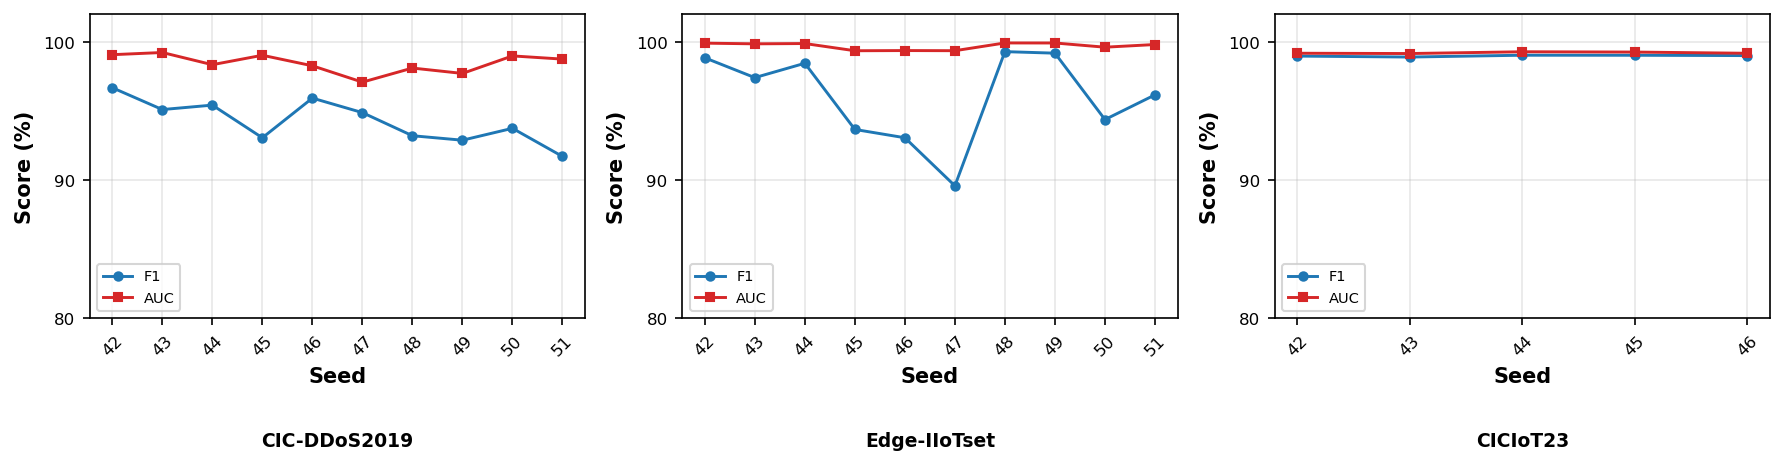

Fig 1 -- Per-seed Test F1 and AUC (%)
------------------------------------------------------------
  CIC-DDoS2019:
    F1  per seed : ['96.70', '95.12', '95.44', '93.07', '95.94', '94.89', '93.22', '92.90', '93.76', '91.72']
    AUC per seed : ['99.09', '99.25', '98.36', '99.05', '98.28', '97.10', '98.12', '97.73', '99.00', '98.77']
    F1  mean±CI  : 94.28 ± 1.13%
    AUC mean±CI  : 98.47 ± 0.49%
  Edge-IIoTset:
    F1  per seed : ['98.86', '97.43', '98.47', '93.68', '93.07', '89.60', '99.31', '99.20', '94.39', '96.18']
    AUC per seed : ['99.92', '99.87', '99.90', '99.37', '99.39', '99.38', '99.94', '99.93', '99.63', '99.82']
    F1  mean±CI  : 96.02 ± 2.33%
    AUC mean±CI  : 99.72 ± 0.18%
  CICIoT23:
    F1  per seed : ['98.99', '98.92', '99.05', '99.05', '99.02']
    AUC per seed : ['99.19', '99.17', '99.30', '99.28', '99.19']
    F1  mean±CI  : 99.00 ± 0.07%
    AUC mean±CI  : 99.23 ± 0.07%



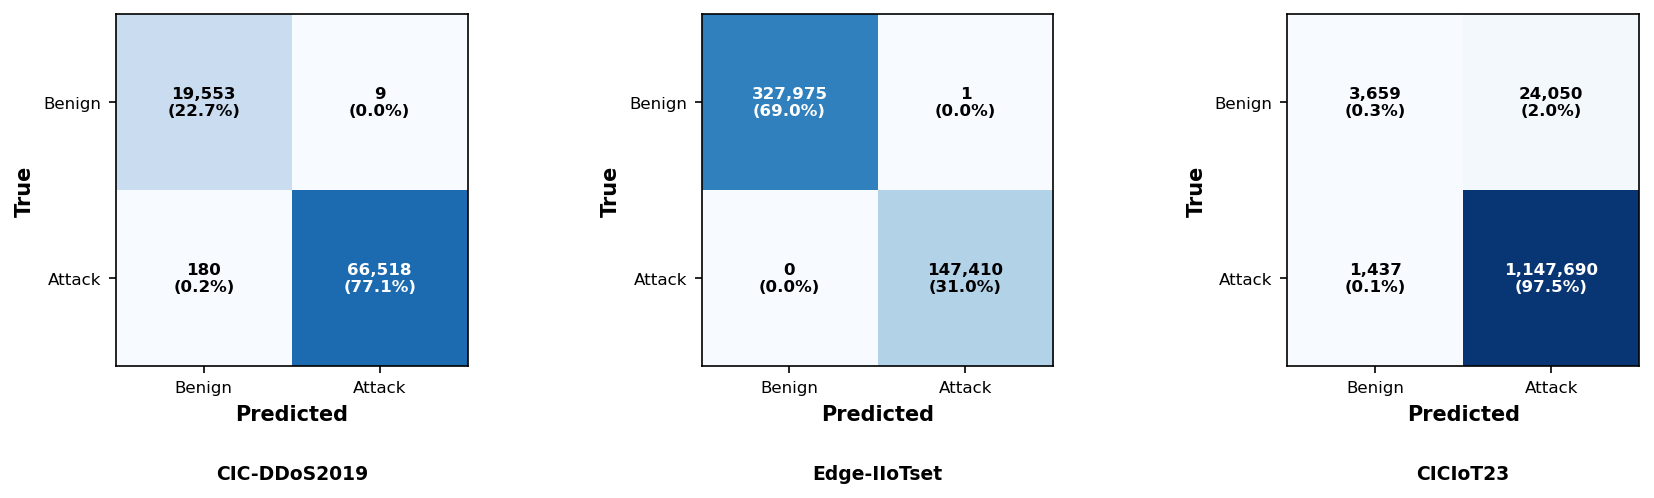

Fig 2 -- Confusion Matrices (count and % of total)
------------------------------------------------------------
  CIC-DDoS2019:
    TN=19,553 (22.7%)  FP=9 (0.0%)
    FN=180 (0.2%)  TP=66,518 (77.1%)
  Edge-IIoTset:
    TN=327,975 (69.0%)  FP=1 (0.0%)
    FN=0 (0.0%)  TP=147,410 (31.0%)
  CICIoT23:
    TN=3,659 (0.3%)  FP=24,050 (2.0%)
    FN=1,437 (0.1%)  TP=1,147,690 (97.5%)



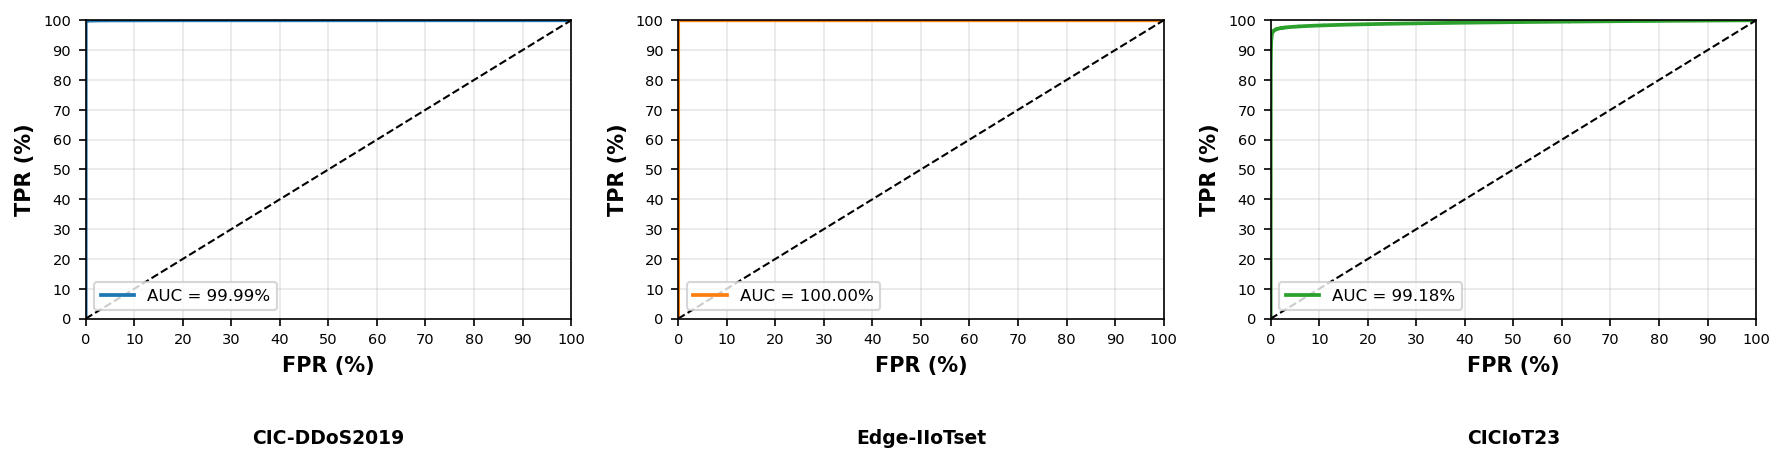

Fig 3 -- ROC Curves
------------------------------------------------------------
  CIC-DDoS2019:  AUC = 99.9911%
  Edge-IIoTset:  AUC = 100.0000%
  CICIoT23:  AUC = 99.1842%



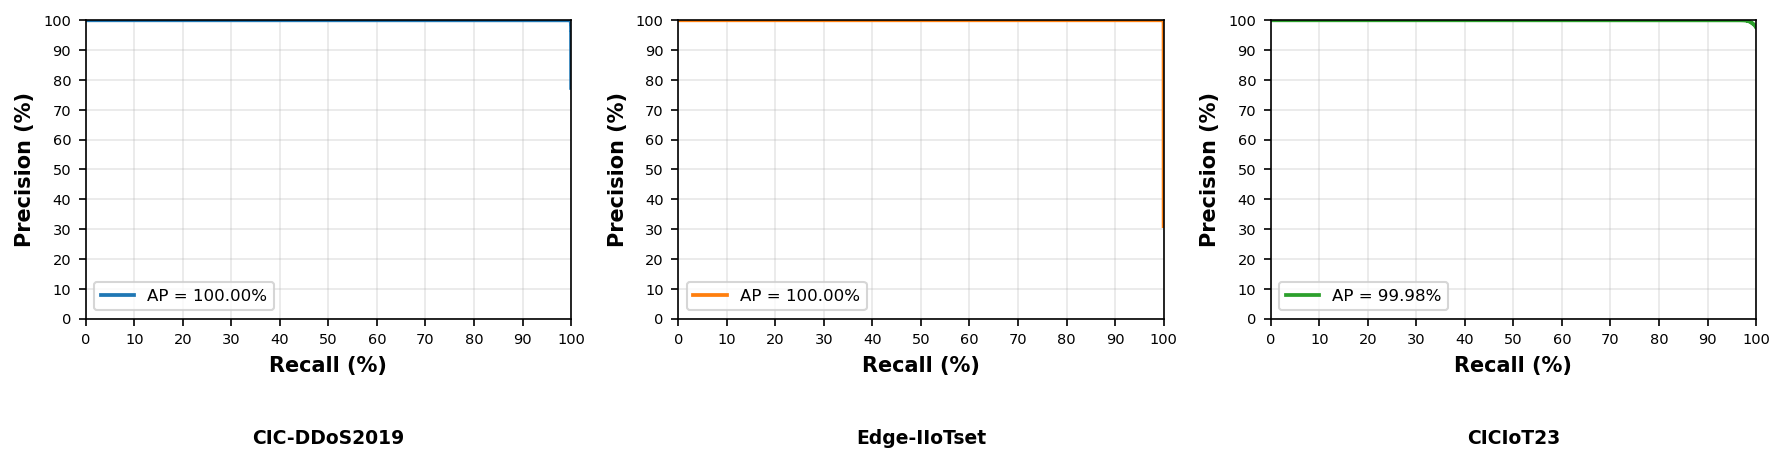

Fig 4 -- Precision-Recall Curves
------------------------------------------------------------
  CIC-DDoS2019:  AP = 99.9975%
  Edge-IIoTset:  AP = 100.0000%
  CICIoT23:  AP = 99.9804%



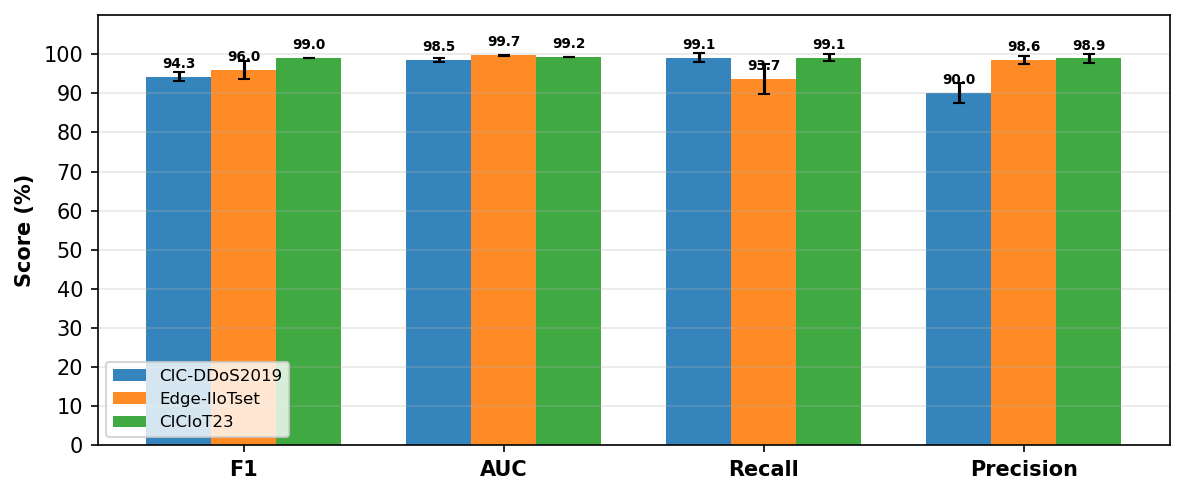

Fig 5 -- Multi-Metric Grouped Bar Chart (mean ± 95% CI across seeds)
------------------------------------------------------------
  CIC-DDoS2019:
    F1          : 94.2758% ± 1.1270%
    AUC         : 98.4746% ± 0.4929%
    Recall      : 99.0509% ± 1.1742%
    Precision   : 90.0413% ± 2.5205%
  Edge-IIoTset:
    F1          : 96.0179% ± 2.3251%
    AUC         : 99.7157% ± 0.1778%
    Recall      : 93.7066% ± 3.8093%
    Precision   : 98.5693% ± 1.0173%
  CICIoT23:
    F1          : 99.0045% ± 0.0676%
    AUC         : 99.2261% ± 0.0719%
    Recall      : 99.1139% ± 0.9694%
    Precision   : 98.9063% ± 1.0793%

Fig 6 (ablation) skipped -- run ablation cell first.

CELL 11 COMPLETE -- all figures saved to outputs/


In [7]:
# CELL 11: Figures
print('CELL 11: Publication Figures\n')

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams.update({
    'font.size': 10, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.labelweight': 'bold',
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'DejaVu Sans'
})

DS_LABELS = {'cic_ddos': 'CIC-DDoS2019', 'edge_iot': 'Edge-IIoTset', 'ciciot23': 'CICIoT23'}
COLOURS   = {'cic_ddos': '#1f77b4', 'edge_iot': '#ff7f0e', 'ciciot23': '#2ca02c'}

# Reconstruct models from saved .pth files
print('Loading models from disk...')
model_pre  = MambaIDS(datasets['cic_ddos']['X_train'].shape[1],
                      PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND,
                      N_LAYERS, DROPOUT).to(device)
model_edge = MambaIDS(datasets['edge_iot']['X_train'].shape[1],
                      PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND,
                      N_LAYERS, DROPOUT, finetune_mode=True).to(device)
model_ciot = MambaIDS(datasets['ciciot23']['X_train'].shape[1],
                      PROJ_DIM, D_MODEL, D_STATE, D_CONV, EXPAND,
                      N_LAYERS, DROPOUT, finetune_mode=True).to(device)

model_pre.load_state_dict(torch.load(OUT / 'mambids_pretrained_cic.pth',
                                     map_location='cpu'))
model_edge.load_state_dict(torch.load(OUT / 'mambids_edge_iot.pth',
                                      map_location='cpu'))
model_ciot.load_state_dict(torch.load(OUT / 'mambids_ciciot23.pth',
                                      map_location='cpu'))
model_pre.eval(); model_edge.eval(); model_ciot.eval()
print('  Models loaded.')

# Reconstruct test loaders
print('Rebuilding test loaders...')
te_ds_cic  = SlidingWindowDataset(datasets['cic_ddos']['X_test'],
                                   datasets['cic_ddos']['y_test'], SEQ_LEN)
te_ds_edge = SlidingWindowDataset(datasets['edge_iot']['X_test'],
                                   datasets['edge_iot']['y_test'], SEQ_LEN)
te_ds_ciot = SlidingWindowDataset(datasets['ciciot23']['X_test'],
                                   datasets['ciciot23']['y_test'], SEQ_LEN)
te_ldr_cic  = DataLoader(te_ds_cic,  BATCH_INFER, shuffle=False, num_workers=0)
te_ldr_edge = DataLoader(te_ds_edge, BATCH_INFER, shuffle=False, num_workers=0)
te_ldr_ciot = DataLoader(te_ds_ciot, BATCH_INFER, shuffle=False, num_workers=0)
print('  Test loaders ready.')

# Load multi-seed results from disk ----
print('Loading multi-seed results from disk...')
multi_seed_results = {
    'cic_ddos': pd.read_csv(OUT / 'multiseed_cic_ddos.csv'),
    'edge_iot': pd.read_csv(OUT / 'multiseed_edge_iot.csv'),
    'ciciot23': pd.read_csv(OUT / 'multiseed_ciciot23.csv'),
}
print('  Multi-seed results loaded.\n')

def ci95(values):
    a  = np.array(values, dtype=float)
    se = stats.sem(a)
    h  = se * stats.t.ppf(0.975, df=len(a) - 1)
    return float(np.mean(a)), float(h)

model_map = {
    'cic_ddos': (model_pre,  te_ldr_cic),
    'edge_iot': (model_edge, te_ldr_edge),
    'ciciot23': (model_ciot, te_ldr_ciot),
}

# Fig 1: Per-seed F1 and AUC stability 
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
fig1_data = {}
for ax, (ds_name, df_ms) in zip(axes, multi_seed_results.items()):
    seeds = df_ms['Seed'].values
    f1s   = df_ms['Fixed_F1'].values * 100
    aucs  = df_ms['Fixed_AUC'].values * 100
    ax.plot(range(len(seeds)), f1s,  'o-', ms=4, lw=1.4,
            color='#1f77b4', label='F1')
    ax.plot(range(len(seeds)), aucs, 's-', ms=4, lw=1.4,
            color='#d62728', label='AUC')
    ax.set_xticks(range(len(seeds)))
    ax.set_xticklabels([str(s) for s in seeds], rotation=45, fontsize=7)
    ax.set_xlabel('Seed', fontweight='bold')
    ax.set_ylabel('Score (%)', fontweight='bold')
    ax.set_ylim(80, 102)
    ax.set_yticks(range(80, 101, 10))
    ax.tick_params(axis='both', labelsize=8)
    ax.text(0.5, -0.42, DS_LABELS[ds_name], transform=ax.transAxes,
            ha='center', fontsize=9, fontweight='bold')
    ax.legend(loc='lower left', fontsize=7, frameon=True)
    ax.grid(True, alpha=0.3)
    fig1_data[ds_name] = {'seeds': seeds, 'f1s': f1s, 'aucs': aucs}
plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
plt.savefig(OUT / 'fig_seed_stability.png', bbox_inches='tight')
plt.show()

print('Fig 1 -- Per-seed Test F1 and AUC (%)')
print('------------------------------------------------------------')
for ds_name, d in fig1_data.items():
    m_f1, h_f1   = ci95(d['f1s'])
    m_auc, h_auc = ci95(d['aucs'])
    print(f'  {DS_LABELS[ds_name]}:')
    print(f'    F1  per seed : {[f"{v:.2f}" for v in d["f1s"]]}')
    print(f'    AUC per seed : {[f"{v:.2f}" for v in d["aucs"]]}')
    print(f'    F1  mean±CI  : {m_f1:.2f} ± {h_f1:.2f}%')
    print(f'    AUC mean±CI  : {m_auc:.2f} ± {h_auc:.2f}%')
print()

# Fig 2: Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
fig2_data = {}
for ax, (ds_name, (mdl, te_ldr)) in zip(axes, model_map.items()):
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in te_ldr:
            xb = torch.nan_to_num(xb, nan=0., posinf=0., neginf=0.)
            p  = torch.sigmoid(mdl(xb.to(device)).squeeze(1)).cpu().numpy()
            probs.extend(p); labels.extend(yb.numpy())
    pred   = (np.array(probs) >= 0.5).astype(int)
    cm     = confusion_matrix(labels, pred, labels=[0, 1])
    cm_pct = cm.astype(float) / cm.sum() * 100
    im     = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benign', 'Attack'], fontsize=8)
    ax.set_yticklabels(['Benign', 'Attack'], fontsize=8)
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('True', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)',
                    ha='center', va='center', fontsize=8, fontweight='bold',
                    color='white' if cm_pct[i,j] > 50 else 'black')
    ax.text(0.5, -0.32, DS_LABELS[ds_name], transform=ax.transAxes,
            ha='center', fontsize=9, fontweight='bold')
    fig2_data[ds_name] = {'cm': cm, 'cm_pct': cm_pct}
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig(OUT / 'fig_confusion_matrices.png', bbox_inches='tight')
plt.show()

print('Fig 2 -- Confusion Matrices (count and % of total)')
print('------------------------------------------------------------')
for ds_name, d in fig2_data.items():
    cm = d['cm']; cp = d['cm_pct']
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    print(f'  {DS_LABELS[ds_name]}:')
    print(f'    TN={tn:,} ({cp[0,0]:.1f}%)  FP={fp:,} ({cp[0,1]:.1f}%)')
    print(f'    FN={fn:,} ({cp[1,0]:.1f}%)  TP={tp:,} ({cp[1,1]:.1f}%)')
print()

# Fig 3: ROC curves
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
fig3_data = {}
for ax, (ds_name, (mdl, te_ldr)) in zip(axes, model_map.items()):
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in te_ldr:
            xb = torch.nan_to_num(xb, nan=0., posinf=0., neginf=0.)
            p  = torch.sigmoid(mdl(xb.to(device)).squeeze(1)).cpu().numpy()
            probs.extend(p); labels.extend(yb.numpy())
    fpr_c, tpr_c, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr_c * 100, tpr_c * 100, color=COLOURS[ds_name], lw=1.8,
            label=f'AUC = {auc*100:.2f}%')
    ax.plot([0, 100], [0, 100], 'k--', lw=1)
    ax.set_xlabel('FPR (%)', fontweight='bold')
    ax.set_ylabel('TPR (%)', fontweight='bold')
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xticks(range(0, 101, 10)); ax.set_yticks(range(0, 101, 10))
    ax.tick_params(axis='both', labelsize=7)
    ax.text(0.5, -0.42, DS_LABELS[ds_name], transform=ax.transAxes,
            ha='center', fontsize=9, fontweight='bold')
    ax.legend(loc='lower left', fontsize=8, frameon=True)
    ax.grid(True, alpha=0.3)
    fig3_data[ds_name] = {'auc': auc}
plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
plt.savefig(OUT / 'fig_roc_curves.png', bbox_inches='tight')
plt.show()

print('Fig 3 -- ROC Curves')
print('------------------------------------------------------------')
for ds_name, d in fig3_data.items():
    print(f'  {DS_LABELS[ds_name]}:  AUC = {d["auc"]*100:.4f}%')
print()

# Fig 4: Precision-Recall curves
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
fig4_data = {}
for ax, (ds_name, (mdl, te_ldr)) in zip(axes, model_map.items()):
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in te_ldr:
            xb = torch.nan_to_num(xb, nan=0., posinf=0., neginf=0.)
            p  = torch.sigmoid(mdl(xb.to(device)).squeeze(1)).cpu().numpy()
            probs.extend(p); labels.extend(yb.numpy())
    prec_c, rec_c, _ = precision_recall_curve(labels, probs)
    ap = average_precision_score(labels, probs)
    ax.plot(rec_c * 100, prec_c * 100, color=COLOURS[ds_name], lw=1.8,
            label=f'AP = {ap*100:.2f}%')
    ax.set_xlabel('Recall (%)', fontweight='bold')
    ax.set_ylabel('Precision (%)', fontweight='bold')
    ax.set_xlim(0, 100); ax.set_ylim(0, 100)
    ax.set_xticks(range(0, 101, 10)); ax.set_yticks(range(0, 101, 10))
    ax.tick_params(axis='both', labelsize=7)
    ax.text(0.5, -0.42, DS_LABELS[ds_name], transform=ax.transAxes,
            ha='center', fontsize=9, fontweight='bold')
    ax.legend(loc='lower left', fontsize=8, frameon=True)
    ax.grid(True, alpha=0.3)
    fig4_data[ds_name] = {'ap': ap}
plt.tight_layout()
plt.subplots_adjust(bottom=0.32)
plt.savefig(OUT / 'fig_pr_curves.png', bbox_inches='tight')
plt.show()

print('Fig 4 -- Precision-Recall Curves')
print('------------------------------------------------------------')
for ds_name, d in fig4_data.items():
    print(f'  {DS_LABELS[ds_name]}:  AP = {d["ap"]*100:.4f}%')
print()

# Fig 5: Multi-metric grouped bar chart
metrics_to_plot = ['Fixed_F1', 'Fixed_AUC', 'Fixed_Rec', 'Fixed_Prec']
metric_labels   = ['F1', 'AUC', 'Recall', 'Precision']
ds_names_plot   = list(multi_seed_results.keys())
x     = np.arange(len(metrics_to_plot))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 3.4))
fig5_data = {}
for i, ds_name in enumerate(ds_names_plot):
    df_ms = multi_seed_results[ds_name]
    means = [df_ms[m].mean() * 100 for m in metrics_to_plot]
    cis   = [ci95(df_ms[m].values)[1] * 100 for m in metrics_to_plot]
    bars  = ax.bar(x + (i-1)*width, means, width, yerr=cis, capsize=3,
                   label=DS_LABELS[ds_name], color=COLOURS[ds_name], alpha=0.9)
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{m:.1f}', ha='center', va='bottom',
                fontsize=6.5, fontweight='bold')
    fig5_data[ds_name] = {'means': means, 'cis': cis}
ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontweight='bold')
ax.set_ylim(0, 110)
ax.set_yticks(range(0, 101, 10))
ax.set_ylabel('Score (%)', fontweight='bold')
ax.legend(loc='lower left', fontsize=8, frameon=True)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'fig_grouped_metrics.png', bbox_inches='tight')
plt.show()

print('Fig 5 -- Multi-Metric Grouped Bar Chart (mean ± 95% CI across seeds)')
print('------------------------------------------------------------')
for ds_name, d in fig5_data.items():
    print(f'  {DS_LABELS[ds_name]}:')
    for lbl, m, c in zip(metric_labels, d['means'], d['cis']):
        print(f'    {lbl:<12s}: {m:.4f}% ± {c:.4f}%')
print()

# Fig 6: Ablation bar chart 
if 'abl_df' in dir():
    fig, ax = plt.subplots(figsize=(8, 3.4))
    variant_labels = [
        v.replace('MambaIDS - ', '')
         .replace('Full MambaIDS (proposed)', 'Proposed (Full)')
        for v in abl_df['Variant']]
    f1_vals = [float(v.split('±')[0]) * 100 for v in abl_df['F1']]
    f1_cis  = [float(v.split('±')[1]) * 100 for v in abl_df['F1']]
    colours_abl = ['#2ca02c' if 'Proposed' in v else '#1f77b4'
                   for v in variant_labels]
    bars = ax.barh(variant_labels, f1_vals, xerr=f1_cis, capsize=3,
                   color=colours_abl, alpha=0.9, height=0.5)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8, fontweight='bold')
    ax.set_xlabel('F1-score (%)', fontweight='bold')
    ax.set_xlim(min(f1_vals) - 2, 100)
    ax.set_xticks(range(int(min(f1_vals)) - 2, 101, 2))
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / 'fig_ablation.png', bbox_inches='tight')
    plt.show()

    print('Fig 6 -- Ablation Study F1-score (%)')
    print('------------------------------------------------------------')
    for lbl, val, ci in zip(variant_labels, f1_vals, f1_cis):
        print(f'  {lbl:<30s}: {val:.4f}% ± {ci:.4f}%')
    print()
else:
    print('Fig 6 (ablation) skipped -- run ablation cell first.')

print('\nCELL 11 COMPLETE -- all figures saved to outputs/')


Running latency benchmark...
  [cic_ddos] TorchScript trace compiled
  [edge_iot] TorchScript trace compiled
  [ciciot23] TorchScript trace compiled



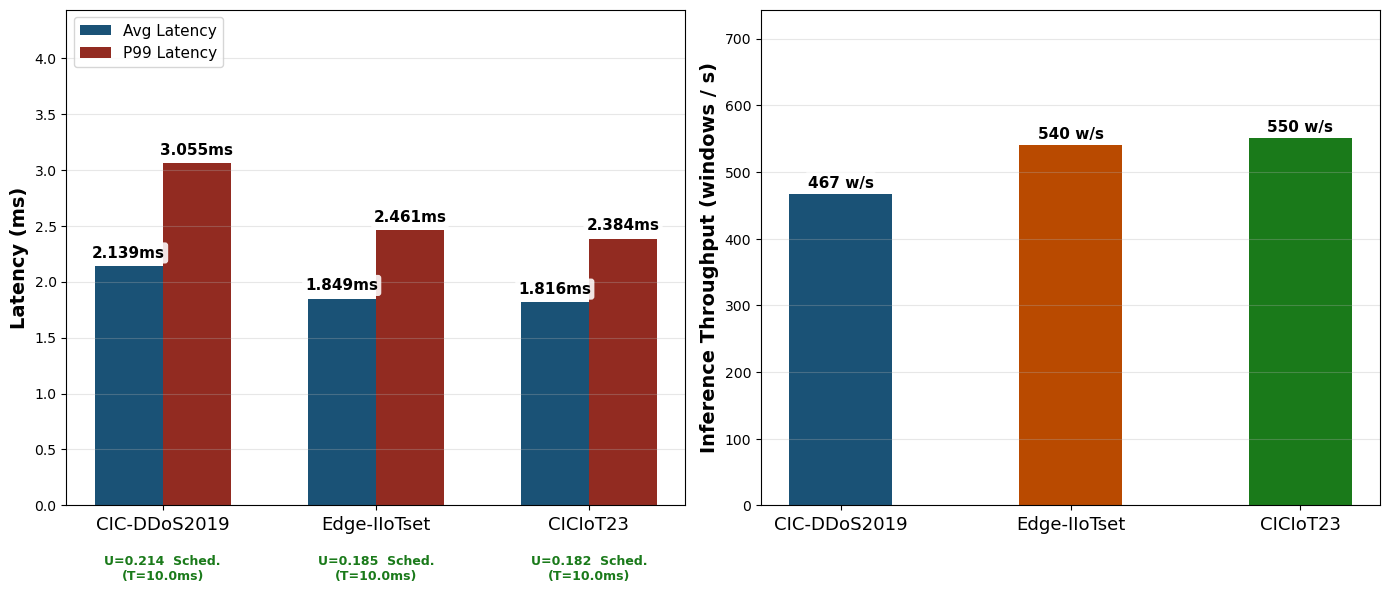

------------------------------------------------------------
Latency and Throughput Results
------------------------------------------------------------

  CIC-DDoS2019
    Avg latency   : 2.1390 ms
    P50 latency   : 2.1132 ms
    P99 latency   : 3.0555 ms
    Inf throughput: 467 windows/s
    Batch tput    : 1600 windows/s
    Utilisation U : 0.2139  (T=10.0ms IIoT period)
    LL bound      : 0.8284
    Schedulable   : True

  Edge-IIoTset
    Avg latency   : 1.8487 ms
    P50 latency   : 1.8019 ms
    P99 latency   : 2.4606 ms
    Inf throughput: 541 windows/s
    Batch tput    : 1601 windows/s
    Utilisation U : 0.1849  (T=10.0ms IIoT period)
    LL bound      : 0.8284
    Schedulable   : True

  CICIoT23
    Avg latency   : 1.8159 ms
    P50 latency   : 1.7601 ms
    P99 latency   : 2.3840 ms
    Inf throughput: 551 windows/s
    Batch tput    : 1595 windows/s
    Utilisation U : 0.1816  (T=10.0ms IIoT period)
    LL bound      : 0.8284
    Schedulable   : True

Fig 6 saved -- l

In [12]:
# Cell 11b: Latency benchmark
print('\nRunning latency benchmark...')

DS_LABELS = {
    'cic_ddos': 'CIC-DDoS2019',
    'edge_iot': 'Edge-IIoTset',
    'ciciot23': 'CICIoT23',
}
COLOURS = {
    'cic_ddos': '#1a5276',
    'edge_iot': '#b94a00',
    'ciciot23': '#1a7a1a',
}

WARMUP = 50; N_RUNS = 500
bench_results = {}

bench_map = {
    'cic_ddos': (model_pre,  datasets['cic_ddos']['X_train'].shape[1]),
    'edge_iot': (model_edge, datasets['edge_iot']['X_train'].shape[1]),
    'ciciot23': (model_ciot, datasets['ciciot23']['X_train'].shape[1]),
}

# Optimise with TorchScript trace to reduce Python dispatch overhead
compiled_map = {}
for ds_name, (mdl, n_feat) in bench_map.items():
    mdl.eval()
    dummy_trace = torch.randn(1, SEQ_LEN, n_feat)
    try:
        traced = torch.jit.trace(mdl, dummy_trace)
        traced.eval()
        compiled_map[ds_name] = (traced, n_feat)
        print(f'  [{ds_name}] TorchScript trace compiled')
    except Exception as e:
        print(f'  [{ds_name}] Trace failed ({e}), using original model')
        compiled_map[ds_name] = (mdl, n_feat)
print()

for ds_name, (mdl, n_feat) in compiled_map.items():
    dummy = torch.randn(1, SEQ_LEN, n_feat)

    with torch.no_grad():
        for _ in range(WARMUP): _ = mdl(dummy)

    lats = []
    with torch.no_grad():
        for _ in range(N_RUNS):
            t0 = time.perf_counter()
            _  = mdl(dummy)
            lats.append((time.perf_counter() - t0) * 1000)

    te_ds_b  = SlidingWindowDataset(datasets[ds_name]['X_test'],
                                     datasets[ds_name]['y_test'], SEQ_LEN)
    te_ldr_b = DataLoader(te_ds_b, BATCH_INFER, shuffle=False, num_workers=0)
    t_start  = time.perf_counter()
    with torch.no_grad():
        for xb, _ in te_ldr_b:
            _ = mdl(xb)
    batch_time = time.perf_counter() - t_start

    avg_lat    = float(np.mean(lats))
    p50_lat    = float(np.percentile(lats, 50))
    p99_lat    = float(np.percentile(lats, 99))
    inf_tput   = 1000.0 / avg_lat
    batch_tput = len(te_ds_b) / batch_time

    T_iot       = 10.0
    U_iot       = avg_lat / T_iot
    U_bound     = 2 * (2**0.5 - 1)
    schedulable = U_iot <= U_bound

    bench_results[ds_name] = {
        'avg_latency_ms': avg_lat,
        'p50_latency_ms': p50_lat,
        'p99_latency_ms': p99_lat,
        'inf_tput_pps':   inf_tput,
        'batch_tput_pps': batch_tput,
        'T_iot_ms':       T_iot,
        'utilisation_U':  U_iot,
        'LL_bound':       U_bound,
        'schedulable':    schedulable,
    }

bench_df = pd.DataFrame(bench_results).T
bench_df.to_csv(OUT / 'latency_benchmark.csv')

# Plot: side-by-side latency (left) and throughput (right)
ds_list  = list(bench_results.keys())
lats     = [bench_results[d]['avg_latency_ms'] for d in ds_list]
p99s     = [bench_results[d]['p99_latency_ms'] for d in ds_list]
tputs    = [bench_results[d]['inf_tput_pps']   for d in ds_list]
labels_b = [DS_LABELS[d] for d in ds_list]

x     = np.arange(len(ds_list))
width = 0.32

COL_AVG  = '#1a5276'
COL_P99  = '#922b21'
COL_TPUT = [COLOURS[d] for d in ds_list]

lbl_kw = dict(fontsize=11, fontweight='bold', color='black',
              bbox=dict(facecolor='white', alpha=0.88,
                        edgecolor='none', boxstyle='round,pad=0.2'))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left panel: Avg and P99 latency
b1 = ax1.bar(x - width/2, lats, width, color=COL_AVG, label='Avg Latency')
b2 = ax1.bar(x + width/2, p99s, width, color=COL_P99, label='P99 Latency')

for bar, val in zip(list(b1) + list(b2), lats + p99s):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.3f}ms', ha='center', va='bottom', **lbl_kw)

ax1.set_ylabel('Latency (ms)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels_b, fontsize=13)
ax1.set_ylim(0, max(p99s) * 1.45)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(axis='y', alpha=0.3)

for i, ds in enumerate(ds_list):
    u     = bench_results[ds]['utilisation_U']
    sched = bench_results[ds]['schedulable']
    T_val = bench_results[ds]['T_iot_ms']
    color = '#1a7a1a' if sched else '#922b21'
    note  = f'U={u:.3f}  {"Sched." if sched else "Not sched."}\n(T={T_val}ms)'
    ax1.text(x[i], -0.10, note,
             ha='center', va='top', fontsize=9, color=color,
             fontweight='bold', transform=ax1.get_xaxis_transform())

# Right panel: inference throughput
b3 = ax2.bar(x, tputs, width * 1.4, color=COL_TPUT, alpha=1.0)

for bar, val in zip(b3, tputs):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{int(val):,} w/s', ha='center', va='bottom', **lbl_kw)

ax2.set_ylabel('Inference Throughput (windows / s)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_b, fontsize=13)
ax2.set_ylim(0, max(tputs) * 1.35)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'fig_latency_throughput.png', bbox_inches='tight')
plt.show()

# Plain text results printed to notebook output (not part of PNG)
print('------------------------------------------------------------')
print('Latency and Throughput Results')
print('------------------------------------------------------------')
for ds in ds_list:
    r = bench_results[ds]
    print(f'\n  {DS_LABELS[ds]}')
    print(f'    Avg latency   : {r["avg_latency_ms"]:.4f} ms')
    print(f'    P50 latency   : {r["p50_latency_ms"]:.4f} ms')
    print(f'    P99 latency   : {r["p99_latency_ms"]:.4f} ms')
    print(f'    Inf throughput: {r["inf_tput_pps"]:.0f} windows/s')
    print(f'    Batch tput    : {r["batch_tput_pps"]:.0f} windows/s')
    print(f'    Utilisation U : {r["utilisation_U"]:.4f}  '
          f'(T={r["T_iot_ms"]}ms IIoT period)')
    print(f'    LL bound      : {r["LL_bound"]:.4f}')
    print(f'    Schedulable   : {r["schedulable"]}')
print('\nFig 6 saved -- latency_benchmark.csv saved.')

In [20]:
# CELL 12: Result Tables 
print('CELL 12: LaTeX Result Tables\n')

import pandas as pd
import numpy as np
from scipy import stats
import json, platform, torch
from pathlib import Path

# Configuration
OUT = Path('outputs')
DS_NICE = {'cic_ddos': 'CIC-DDoS2019', 'edge_iot': 'Edge-IIoTset', 'ciciot23': 'CICIoT23'}

# Helper functions
def ci95(values):
    a = np.array(values, dtype=float)
    se = stats.sem(a)
    h = se * stats.t.ppf(0.975, df=len(a)-1)
    return float(np.mean(a)), float(h)

#  Load multi‑seed results 
multi_seed_results = {
    'cic_ddos': pd.read_csv(OUT / 'multiseed_cic_ddos.csv'),
    'edge_iot': pd.read_csv(OUT / 'multiseed_edge_iot.csv'),
    'ciciot23': pd.read_csv(OUT / 'multiseed_ciciot23.csv'),
}

# Load ablation results
if (OUT / 'ablation_results.csv').exists():
    abl_df = pd.read_csv(OUT / 'ablation_results.csv')
else:
    abl_df = None
    print('  Warning: ablation_results.csv not found, skipping Table 2.')

# Load latency benchmark 
if (OUT / 'latency_benchmark.csv').exists():
    bench_df = pd.read_csv(OUT / 'latency_benchmark.csv', index_col=0)
    bench_results = bench_df.to_dict('index')
else:
    bench_results = {}
    print('  Warning: latency_benchmark.csv not found, skipping Table 3.')

#  Table 1: Main results 
print('\n% Table 1: MambaIDS Main Results (10 seeds, 95% CI)')
print(r'\begin{table}[H]')
print(r'\centering')
print(r'\caption{MambaIDS test performance across three datasets (mean $\pm$ 95\% CI, 10 seeds).}')
print(r'\label{tab:mambids_main}')
print(r'\begin{tabular}{lcccccc}')
print(r'\toprule')
print(r'\textbf{Dataset} & \textbf{Acc} & \textbf{F1} & \textbf{Prec} & \textbf{Rec} & \textbf{FPR} & \textbf{AUC} \\')
print(r'\midrule')
for ds_name, df_ms in multi_seed_results.items():
    # Use Fixed_ metrics (standard 0.5 threshold)
    def fmt(col): 
        m, h = ci95(df_ms[col])
        return f'${m:.4f}\\pm{h:.4f}$'
    row = ' & '.join([
        DS_NICE[ds_name],
        fmt('Fixed_Acc'), fmt('Fixed_F1'), fmt('Fixed_Prec'),
        fmt('Fixed_Rec'), fmt('Fixed_FPR'), fmt('Fixed_AUC')
    ])
    print(row + r' \\')
print(r'\bottomrule')
print(r'\end{tabular}')
print(r'\end{table}')

# Table 2: Ablation study 
if abl_df is not None:
    print('\n% Table 2: Ablation Study (CICIoT23, 3 seeds)')
    print(r'\begin{table}[H]')
    print(r'\centering')
    print(r'\caption{Ablation study on CICIoT23 (mean $\pm$ 95\% CI, 3 seeds).}')
    print(r'\label{tab:ablation}')
    print(r'\begin{tabular}{lcccc}')
    print(r'\toprule')
    print(r'\textbf{Variant} & \textbf{Acc} & \textbf{F1} & \textbf{FPR} & \textbf{FNR} \\')
    print(r'\midrule')
    for _, row in abl_df.iterrows():
        # Clean variant names
        name = row['Variant'].replace('MambaIDS — ', 'w/o ')
        if name == 'Full MambaIDS (proposed)':
            name = r'\textbf{Full MambaIDS (proposed)}'
        print(f'{name} & {row["Acc"]} & {row["F1"]} & {row["FPR"]} & {row["FNR"]} \\\\')
    print(r'\bottomrule')
    print(r'\end{tabular}')
    print(r'\end{table}')

# Table 3: Latency & throughput 
if bench_results:
    print('\n% Table 3: Inference Latency and Throughput')
    print(r'\begin{table}[H]')
    print(r'\centering')
    print(r'\caption{MambaIDS inference latency and throughput on CPU-only hardware.}')
    print(r'\label{tab:latency}')
    print(r'\begin{tabular}{lccccc}')
    print(r'\toprule')
    print(r'\textbf{Dataset} & \textbf{Avg (ms)} & \textbf{P99 (ms)} & \textbf{Inf-only (pkt/s)} & \textbf{Batch (pkt/s)} & \textbf{Schedulable} \\')
    print(r'\midrule')
    for ds_name, br in bench_results.items():
        sched = r'\checkmark' if br.get('schedulable', False) else r'\times'
        print(f'{DS_NICE[ds_name]} & {br["avg_latency_ms"]:.4f} & {br["p99_latency_ms"]:.4f} & '
              f'{br["inf_tput_pps"]:,.0f} & {br["batch_tput_pps"]:,.0f} & ${sched}$ \\\\')
    print(r'\bottomrule')
    print(r'\end{tabular}')
    print(r'\end{table}')

# Reproducibility metadata 
# Load constants from Cell 1 if they exist (use defaults otherwise)
try:
    # If these are not defined (e.g., kernel restart), use defaults from notebook
    PROJ_DIM = PROJ_DIM if 'PROJ_DIM' in dir() else 39
    D_MODEL = D_MODEL if 'D_MODEL' in dir() else 64
    D_STATE = D_STATE if 'D_STATE' in dir() else 16
    D_CONV = D_CONV if 'D_CONV' in dir() else 4
    EXPAND = EXPAND if 'EXPAND' in dir() else 2
    N_LAYERS = N_LAYERS if 'N_LAYERS' in dir() else 2
    SEQ_LEN = SEQ_LEN if 'SEQ_LEN' in dir() else 16
    N_SEEDS = N_SEEDS if 'N_SEEDS' in dir() else 10
    DROPOUT = DROPOUT if 'DROPOUT' in dir() else 0.25
    LR_PRE = LR_PRE if 'LR_PRE' in dir() else 1e-3
    LR_FT = LR_FT if 'LR_FT' in dir() else 3e-4
except:
    pass

repro = {
    'torch_version':   torch.__version__,
    'numpy_version':   np.__version__,
    'sklearn_version': __import__('sklearn').__version__,
    'python_version':  platform.python_version(),
    'device':          str(torch.device('cuda' if torch.cuda.is_available() else 'cpu')),
    'PROJ_DIM':        PROJ_DIM, 'D_MODEL': D_MODEL,
    'D_STATE':         D_STATE,  'D_CONV':  D_CONV,
    'EXPAND':          EXPAND,   'N_LAYERS': N_LAYERS,
    'SEQ_LEN':         SEQ_LEN,  'N_SEEDS': N_SEEDS,
    'DROPOUT':         DROPOUT,  'LR_PRE':  LR_PRE, 'LR_FT': LR_FT,
}
with open(OUT / 'repro_metadata.json', 'w') as f:
    json.dump(repro, f, indent=2)
print('\nReproducibility metadata saved.')

print('\nCELL 12 COMPLETE : all tables printed above')

CELL 12: LaTeX Result Tables


% Table 1: MambaIDS Main Results (10 seeds, 95% CI)
\begin{table}[H]
\centering
\caption{MambaIDS test performance across three datasets (mean $\pm$ 95\% CI, 10 seeds).}
\label{tab:mambids_main}
\begin{tabular}{lcccccc}
\toprule
\textbf{Dataset} & \textbf{Acc} & \textbf{F1} & \textbf{Prec} & \textbf{Rec} & \textbf{FPR} & \textbf{AUC} \\
\midrule
CIC-DDoS2019 & $0.9065\pm0.0198$ & $0.9428\pm0.0113$ & $0.9004\pm0.0252$ & $0.9905\pm0.0117$ & $0.3800\pm0.1069$ & $0.9847\pm0.0049$ \\
Edge-IIoTset & $0.9763\pm0.0134$ & $0.9602\pm0.0233$ & $0.9857\pm0.0102$ & $0.9371\pm0.0381$ & $0.0060\pm0.0044$ & $0.9972\pm0.0018$ \\
CICIoT23 & $0.9805\pm0.0015$ & $0.9900\pm0.0007$ & $0.9891\pm0.0108$ & $0.9911\pm0.0097$ & $0.4594\pm0.4557$ & $0.9923\pm0.0007$ \\
\bottomrule
\end{tabular}
\end{table}

% Table 2: Ablation Study (CICIoT23, 3 seeds)
\begin{table}[H]
\centering
\caption{Ablation study on CICIoT23 (mean $\pm$ 95\% CI, 3 seeds).}
\label{tab:ablation}
\begin{tabular}